In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import os

# Define directories
base_dir = '/home/a/projects/Complete-Neural-Signal-Analysis'

# Load EEG data
EEG_data = np.load(os.path.join(base_dir, 'eeg_data_with_channels.npy'), allow_pickle=True)

sampling_rate = 1000  # Hz
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
filtered_EEG_data = EEG_data[start_index:end_index, :]

import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Define the min_samples value you plan to use with UMAP
min_samples = 10

# Load EEG data (the following is an example path, replace with the actual path to your EEG data)
EEG_data = filtered_EEG_data

# EEG channel names
eeg_channel_names = ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
                     'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
                     'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2']

# Create a figure for plotting
plt.figure(figsize=(14, 8))

# Loop through all channels and plot the elbow plot for each
for channel_index, channel_name in enumerate(eeg_channel_names):
    # Select the data for the current channel
    channel_data = EEG_data[:, channel_index].reshape(-1, 1)  # Reshape for NearestNeighbors
    
    neighbors = NearestNeighbors(n_neighbors=min_samples).fit(channel_data)
    distances, indices = neighbors.kneighbors(channel_data)

    # Sort the distances
    distances = np.sort(distances[:, min_samples-1], axis=0)

    # Plotting the elbow plot for the first 1000 points of the current channel
    plt.plot(distances[:1000], label=channel_name)

plt.xlabel('Point')
plt.ylabel('Distance to 10th nearest neighbor')
plt.title('Sorted distances to 10th nearest neighbor for all channels')
plt.legend(loc='upper right')  # Adjust the legend location so it doesn't overlap the lines
plt.show()

### UMAP and t-SNE

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

embedding_3d_dir = os.path.join(base_dir, "embedding_data", "3dembedding_data")
plots_dir = os.path.join(base_dir, "plots", "tsne_umap_from_3d")
embeddings_dir = os.path.join(base_dir, "embedding_data", "tsne_umap_from_3d")

os.makedirs(plots_dir, exist_ok=True)
os.makedirs(embeddings_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# UMAP parameters
n_components_umap = 2
n_neighbors_umap = 15
min_dist_umap = 0.1
random_state_umap = 42

# t-SNE parameters
n_components_tsne = 2
perplexity_tsne = 30
random_state_tsne = 42

# Speed controls
# UMAP uses full data
# t-SNE uses a reproducible 10k-point subsample
tsne_max_points = 10000

# Plotting controls
# UMAP plot may still be subsampled for faster plotting only
plot_max_points_umap = 15000

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

rng = np.random.default_rng(42)

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.20, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# DATA HELPERS
# -------------------------------------------------------
def standardize_columns(X):
    X = np.asarray(X, dtype=float)
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, keepdims=True) + 1e-12
    return (X - mu) / sd

def subsample_rows(X, max_points=15000, rng=None):
    X = np.asarray(X)
    if rng is None:
        rng = np.random.default_rng()

    n = len(X)
    if max_points is None or n <= max_points:
        return X

    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx]

# -------------------------------------------------------
# MANIFOLD METHODS
# -------------------------------------------------------
def apply_umap(data, n_components=2, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="euclidean",
        random_state=random_state,
        transform_seed=random_state,
        low_memory=True
    )
    return reducer.fit_transform(data)

def apply_tsne(data, n_components=2, perplexity=30, random_state=42):
    tsne = TSNE(
        n_components=n_components,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate="auto",
        method="barnes_hut",
        angle=0.5
    )
    return tsne.fit_transform(data)

# -------------------------------------------------------
# MAIN LOOP
# -------------------------------------------------------
summary_rows = []

for channel_name in eeg_channel_names:
    data_path = os.path.join(embedding_3d_dir, f"3dembedded_{channel_name}.npy")

    if not os.path.exists(data_path):
        print(f"Missing file for {channel_name}: {data_path}")
        continue

    channel_data_3d = np.load(data_path)
    channel_data_3d = np.asarray(channel_data_3d, dtype=float)

    if channel_data_3d.ndim != 2 or channel_data_3d.shape[1] != 3:
        print(f"Skipping {channel_name}: expected shape (N, 3), got {channel_data_3d.shape}")
        continue

    # Standardize before manifold learning
    X = standardize_columns(channel_data_3d)

    print(f"\nProcessing {channel_name} | full shape={X.shape}")

    # -------------------------
    # UMAP on full data
    # -------------------------
    t0 = time.perf_counter()
    umap_embedding = apply_umap(
        X,
        n_components=n_components_umap,
        n_neighbors=n_neighbors_umap,
        min_dist=min_dist_umap,
        random_state=random_state_umap
    )
    umap_time = time.perf_counter() - t0

    # -------------------------
    # t-SNE on 10k-point subsample
    # -------------------------
    X_tsne = subsample_rows(X, max_points=tsne_max_points, rng=rng)

    t0 = time.perf_counter()
    tsne_embedding = apply_tsne(
        X_tsne,
        n_components=n_components_tsne,
        perplexity=perplexity_tsne,
        random_state=random_state_tsne
    )
    tsne_time = time.perf_counter() - t0

    # -------------------------
    # SAVE EMBEDDINGS
    # -------------------------
    umap_path = os.path.join(embeddings_dir, f"umap_embedding_{channel_name}.npy")
    tsne_path = os.path.join(embeddings_dir, f"tsne_embedding_{channel_name}.npy")

    np.save(umap_path, umap_embedding)
    np.save(tsne_path, tsne_embedding)

    # -------------------------
    # PLOT UMAP (subsample for plotting only)
    # -------------------------
    umap_plot = subsample_rows(umap_embedding, max_points=plot_max_points_umap, rng=rng)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    style_ax(ax)
    ax.scatter(
        umap_plot[:, 0], umap_plot[:, 1],
        s=5, color=ACCENT
    )
    ax.set_title(f"UMAP for {channel_name} | n={X.shape[0]}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, f"UMAP_{channel_name}.png"), dpi=150, bbox_inches="tight")
    plt.close()

    # -------------------------
    # PLOT t-SNE (already subsampled to 10k)
    # -------------------------
    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    style_ax(ax)
    ax.scatter(
        tsne_embedding[:, 0], tsne_embedding[:, 1],
        s=5, color=ACCENT
    )
    ax.set_title(f"t-SNE for {channel_name} | n={X_tsne.shape[0]}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, f"tSNE_{channel_name}.png"), dpi=150, bbox_inches="tight")
    plt.close()

    summary_rows.append({
        "channel": channel_name,
        "n_points_full": X.shape[0],
        "n_points_used_for_umap": X.shape[0],
        "n_points_used_for_tsne": X_tsne.shape[0],
        "umap_time_sec": umap_time,
        "tsne_time_sec": tsne_time,
        "umap_file": os.path.basename(umap_path),
        "tsne_file": os.path.basename(tsne_path),
    })

    print(
        f"Saved {channel_name} | "
        f"UMAP: {umap_embedding.shape} in {umap_time:.2f}s | "
        f"t-SNE: {tsne_embedding.shape} in {tsne_time:.2f}s"
    )

# -------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------
if len(summary_rows) > 0:
    summary_df = pd.DataFrame(summary_rows)
    summary_csv = os.path.join(embeddings_dir, "tsne_umap_summary.csv")
    summary_df.to_csv(summary_csv, index=False)
    print(f"\nSaved summary CSV: {summary_csv}")

print("\nAll processes completed successfully.")

### 4D to 10D TMAP and t-SNE

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

embedding_in_dir = os.path.join(base_dir, "embedding_data", "embeddings_4to10")
embeddings_out_dir = os.path.join(base_dir, "embedding_data", "tsne_umap_4to10")
plots_out_dir = os.path.join(base_dir, "plots", "tsne_umap_4to10")

os.makedirs(embeddings_out_dir, exist_ok=True)
os.makedirs(plots_out_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

emb_dims = list(range(4, 11))  # 4..10 inclusive

# UMAP parameters
n_components_umap = 2
n_neighbors_umap = 15
min_dist_umap = 0.1
random_state_umap = 42

# t-SNE parameters
n_components_tsne = 2
perplexity_tsne = 30
random_state_tsne = 42

# For speed:
# - full embeddings are still computed on all rows by default
# - only plotting is subsampled
plot_max_points = 15000

# If runtime becomes too large, set compute_max_points to an integer like 15000 or 20000.
# Keeping it None preserves full fidelity for the manifold computation.
compute_max_points = None

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

rng = np.random.default_rng(42)

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.20, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def standardize_columns(X):
    X = np.asarray(X, dtype=float)
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, keepdims=True) + 1e-12
    return (X - mu) / sd

def subsample_rows(X, max_points=15000, rng=None):
    X = np.asarray(X)
    if rng is None:
        rng = np.random.default_rng()

    n = len(X)
    if max_points is None or n <= max_points:
        return X

    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx]

def apply_umap(data, n_components=2, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="euclidean",
        random_state=random_state,
        transform_seed=random_state,
        low_memory=True
    )
    return reducer.fit_transform(data)

def apply_tsne(data, n_components=2, perplexity=30, random_state=42):
    tsne = TSNE(
        n_components=n_components,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate="auto",
        method="barnes_hut",
        angle=0.5
    )
    return tsne.fit_transform(data)

# -------------------------------------------------------
# MAIN LOOP
# -------------------------------------------------------
summary_rows = []

for emb_dim in emb_dims:
    print(f"\n==================== m = {emb_dim} ====================")

    for channel_name in eeg_channel_names:
        in_path = os.path.join(embedding_in_dir, f"{emb_dim}dembedded_{channel_name}.npy")

        if not os.path.exists(in_path):
            print(f"Missing: {in_path}")
            continue

        X = np.load(in_path)
        X = np.asarray(X, dtype=float)

        if X.ndim != 2 or X.shape[1] != emb_dim:
            print(f"Skipping {channel_name}, m={emb_dim}: expected (*,{emb_dim}), got {X.shape}")
            continue

        # standardize before manifold learning
        X_std = standardize_columns(X)

        # optional compute-time subsample
        X_compute = subsample_rows(X_std, max_points=compute_max_points, rng=rng)

        print(f"Processing {channel_name} | m={emb_dim} | full={X.shape} | compute={X_compute.shape}")

        # -------------------------
        # UMAP
        # -------------------------
        t0 = time.perf_counter()
        umap_embedding = apply_umap(
            X_compute,
            n_components=n_components_umap,
            n_neighbors=n_neighbors_umap,
            min_dist=min_dist_umap,
            random_state=random_state_umap
        )
        umap_time = time.perf_counter() - t0

        # -------------------------
        # t-SNE
        # -------------------------
        t0 = time.perf_counter()
        tsne_embedding = apply_tsne(
            X_compute,
            n_components=n_components_tsne,
            perplexity=perplexity_tsne,
            random_state=random_state_tsne
        )
        tsne_time = time.perf_counter() - t0

        # -------------------------
        # SAVE EMBEDDINGS
        # -------------------------
        umap_file = f"umap_m{emb_dim}_{channel_name}.npy"
        tsne_file = f"tsne_m{emb_dim}_{channel_name}.npy"

        umap_path = os.path.join(embeddings_out_dir, umap_file)
        tsne_path = os.path.join(embeddings_out_dir, tsne_file)

        np.save(umap_path, umap_embedding)
        np.save(tsne_path, tsne_embedding)

        # -------------------------
        # SUBSAMPLE FOR PLOTTING ONLY
        # -------------------------
        umap_plot = subsample_rows(umap_embedding, max_points=plot_max_points, rng=rng)
        tsne_plot = subsample_rows(tsne_embedding, max_points=plot_max_points, rng=rng)

        # -------------------------
        # UMAP PLOT
        # -------------------------
        fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
        style_ax(ax)
        ax.scatter(
            umap_plot[:, 0], umap_plot[:, 1],
            s=5, color=ACCENT
        )
        ax.set_title(f"UMAP | {channel_name} | m={emb_dim}")
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        plt.tight_layout()
        plt.savefig(
            os.path.join(plots_out_dir, f"UMAP_m{emb_dim}_{channel_name}.png"),
            dpi=150,
            bbox_inches="tight"
        )
        plt.close()

        # -------------------------
        # t-SNE PLOT
        # -------------------------
        fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
        style_ax(ax)
        ax.scatter(
            tsne_plot[:, 0], tsne_plot[:, 1],
            s=5, color=ACCENT
        )
        ax.set_title(f"t-SNE | {channel_name} | m={emb_dim}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        plt.tight_layout()
        plt.savefig(
            os.path.join(plots_out_dir, f"tSNE_m{emb_dim}_{channel_name}.png"),
            dpi=150,
            bbox_inches="tight"
        )
        plt.close()

        summary_rows.append({
            "channel": channel_name,
            "emb_dim": emb_dim,
            "n_points_full": X.shape[0],
            "n_points_used_for_compute": X_compute.shape[0],
            "ambient_dim": X.shape[1],
            "umap_time_sec": umap_time,
            "tsne_time_sec": tsne_time,
            "umap_file": umap_file,
            "tsne_file": tsne_file,
        })

        print(
            f"Saved {channel_name} | m={emb_dim} | "
            f"UMAP {umap_embedding.shape} in {umap_time:.2f}s | "
            f"t-SNE {tsne_embedding.shape} in {tsne_time:.2f}s"
        )

# -------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(embeddings_out_dir, "tsne_umap_4to10_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print(f"\nSaved summary CSV: {summary_csv}")
print("Done.")

KeyboardInterrupt: 

### Riemannian geometry


<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis utilizes Riemannian geometry to process and visualize EEG data. By computing covariance matrices for segmented EEG epochs and determining their Riemannian mean, we can gain insights into the underlying brain dynamics.</p>
        <h2>Data Segmentation</h2>
        <p>The continuous EEG data is segmented into fixed-length epochs to facilitate subsequent analysis.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Number of epochs} = \left\lfloor \frac{\text{Total samples}}{\text{Samples per epoch}} \right\rfloor
        \]
        where \(\text{Samples per epoch} = \text{Window size} \times \text{Sampling rate}\).</p>
        <h2>Covariance Matrices</h2>
        <p>For each epoch, a covariance matrix is computed to capture the statistical dependencies between different EEG channels.</p>
        <p><strong>Formula:</strong></p>
        \[
        \mathbf{C} = \frac{1}{N-1} (\mathbf{X} - \mathbf{\bar{X}}) (\mathbf{X} - \mathbf{\bar{X}})^T
        \]
        where \(\mathbf{X}\) is the data matrix for an epoch, \(N\) is the number of samples, and \(\mathbf{\bar{X}}\) is the mean vector.</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Riemannian Mean</h2>
        <p>The Riemannian mean of the covariance matrices provides a robust average that respects the manifold structure of symmetric positive-definite matrices.</p>
        <p><strong>Formula:</strong></p>
        \[
        \mathbf{C}_{\text{mean}} = \arg \min_{\mathbf{C}} \sum_{i} \delta^2(\mathbf{C}, \mathbf{C}_i)
        \]
        where \(\delta\) is the Riemannian distance between covariance matrices.</p>
        <h2>Visualization</h2>
        <p>The Riemannian mean of the covariance matrices is visualized as a heatmap. A custom colormap is used to enhance the visual representation.</p>
        <p><strong>Steps:</strong></p>
        <ul>
            <li>Compute the covariance matrices for each epoch.</li>
            <li>Calculate the Riemannian mean of these covariance matrices.</li>
            <li>Visualize the Riemannian mean using a heatmap with a custom colormap.</li>
        </ul>
        <h2>Custom Colormap</h2>
        <p>A custom colormap ranging from yellow to red is used to represent the magnitude of the covariance values.</p>
        <p><strong>Colors:</strong></p>
        \[
        \text{Colors} = \{(1, 1, 0), (1, 0.5, 0), (1, 0, 0)\}
        \]
        <h2>Plot Customization</h2>
        <p>The plot aesthetics are customized with a black background, red labels, and a red grid for enhanced visual appeal.</p>
        <h2>Conclusion</h2>
        <p>This methodology leverages Riemannian geometry to provide a nuanced analysis of EEG data, capturing complex inter-channel dependencies and presenting them in an informative visual format.</p>
    </div>
</div>


Loaded EEG segment shape: (106944, 32)
Segment: [814.571, 921.515] sec
Segmented EEG shape (epochs, channels, timepoints): (106, 32, 1000)
Covariance matrices shape: (106, 32, 32)
Iteration 01 | tangent Fro norm = 2.882808e+00
Iteration 02 | tangent Fro norm = 1.282943e-01
Iteration 03 | tangent Fro norm = 1.055107e-02
Iteration 04 | tangent Fro norm = 1.216718e-03
Iteration 05 | tangent Fro norm = 1.920605e-04
Iteration 06 | tangent Fro norm = 3.435660e-05
Iteration 07 | tangent Fro norm = 6.390986e-06
Iteration 08 | tangent Fro norm = 1.210713e-06
Iteration 09 | tangent Fro norm = 2.324567e-07
Iteration 10 | tangent Fro norm = 4.518800e-08

Riemannian mean computed.
Iterations used: 10
Final update norm: 4.518800009482308e-08


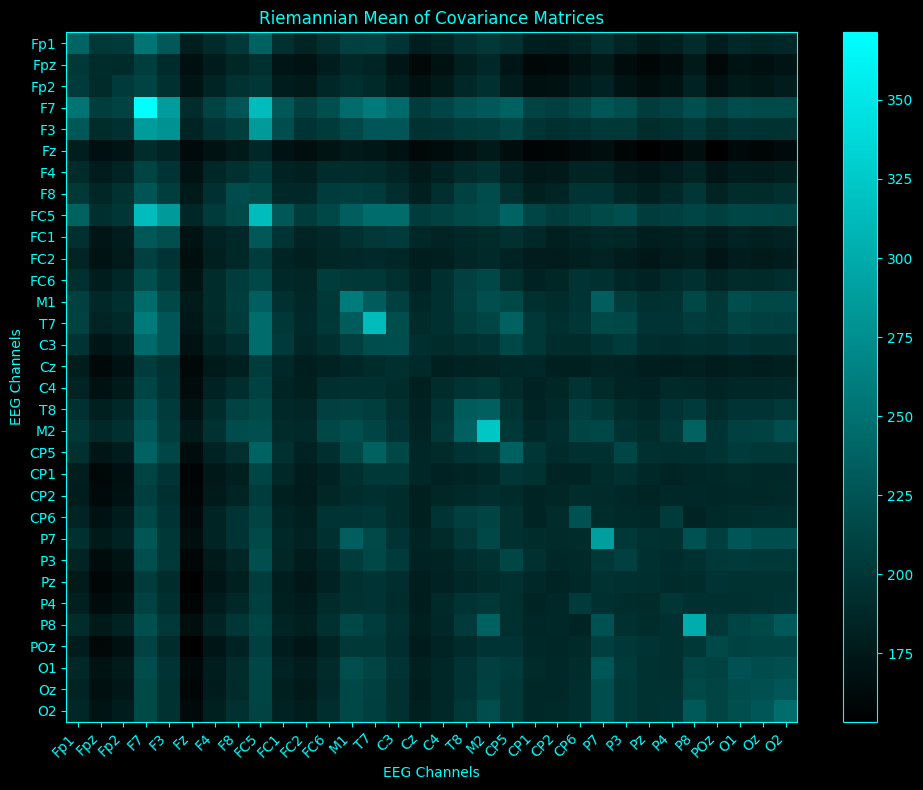

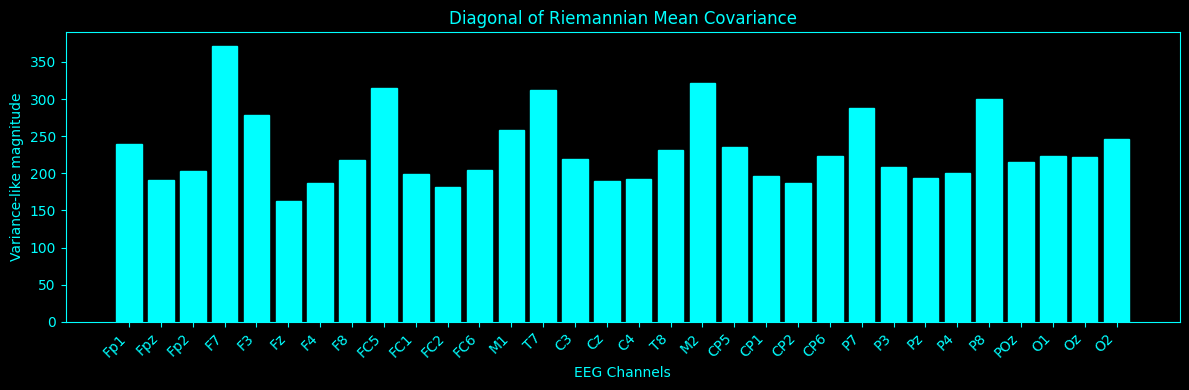


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_covariance_analysis
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_covariance_analysis/riemannian_covariance_results.npz
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_covariance_analysis/riemannian_covariance_summary.txt
Saved heatmap: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_covariance_analysis/plots/riemannian_mean_heatmap.png
Saved diagonal plot: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_covariance_analysis/plots/riemannian_mean_diagonal.png


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

window_size_sec = 1.0
samples_per_window = int(window_size_sec * sampling_rate)

# Small diagonal regularization so covariances stay SPD
cov_reg = 1e-6

# Riemannian mean settings
max_iter = 50
tol = 1e-7

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD MATRIX HELPERS (OWN MATH)
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def sqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w)
    return (V * np.sqrt(w)) @ V.T

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w)
    return (V * np.log(w)) @ V.T

def expm_sym(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    return (V * np.exp(w)) @ V.T

# -------------------------------------------------------
# DATA HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(EEG_data, n_channels_expected):
    EEG_data = np.asarray(EEG_data, dtype=float)

    if EEG_data.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

    if EEG_data.shape[1] == n_channels_expected:
        return EEG_data
    elif EEG_data.shape[0] == n_channels_expected:
        return EEG_data.T
    else:
        raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

def segment_data(EEG_data_tc, samples_per_window):
    """
    EEG_data_tc shape: (time, channels)
    Returns: (epochs, channels, timepoints)
    """
    total_samples, n_channels = EEG_data_tc.shape
    n_windows = total_samples // samples_per_window

    if n_windows < 1:
        raise ValueError("Not enough samples for even one full window.")

    trimmed = EEG_data_tc[:n_windows * samples_per_window]
    segmented = trimmed.reshape(n_windows, samples_per_window, n_channels)
    segmented = np.transpose(segmented, (0, 2, 1))
    return segmented

def compute_cov_matrices(segmented_data, reg=1e-6):
    """
    segmented_data shape: (epochs, channels, timepoints)
    returns covariance matrices: (epochs, channels, channels)
    """
    epochs, n_channels, n_time = segmented_data.shape

    # center each epoch/channel along time axis
    X = segmented_data - np.mean(segmented_data, axis=2, keepdims=True)

    # vectorized covariance
    covs = np.matmul(X, np.transpose(X, (0, 2, 1))) / max(n_time - 1, 1)

    # regularize
    eye = np.eye(n_channels)[None, :, :]
    covs = covs + reg * eye

    # enforce symmetry
    covs = 0.5 * (covs + np.transpose(covs, (0, 2, 1)))
    return covs

# -------------------------------------------------------
# RIEMANNIAN MEAN (AFFINE-INVARIANT / KARCHER MEAN)
# -------------------------------------------------------
def compute_riemannian_mean(cov_matrices, max_iter=50, tol=1e-7, verbose=True):
    """
    Affine-invariant Riemannian mean of SPD matrices.

    cov_matrices shape: (n_mats, n, n)
    """
    cov_matrices = np.asarray(cov_matrices, dtype=float)
    n_mats, n, _ = cov_matrices.shape

    # initialize with arithmetic mean
    G = symmetrize(np.mean(cov_matrices, axis=0))

    for it in range(max_iter):
        G_sqrt = sqrtm_spd(G)
        G_invsqrt = invsqrtm_spd(G)

        tangent_sum = np.zeros((n, n), dtype=float)

        for C in cov_matrices:
            inner = G_invsqrt @ C @ G_invsqrt
            tangent_sum += logm_spd(inner)

        tangent_mean = tangent_sum / n_mats
        update_norm = np.linalg.norm(tangent_mean, ord="fro")

        if verbose:
            print(f"Iteration {it+1:02d} | tangent Fro norm = {update_norm:.6e}")

        if update_norm < tol:
            break

        G = G_sqrt @ expm_sym(tangent_mean) @ G_sqrt
        G = symmetrize(G)

    return G, it + 1, update_norm

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_data = EEG_data[start_index:end_index, :]

print(f"Loaded EEG segment shape: {EEG_data.shape}")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# SEGMENT INTO EPOCHS
# -------------------------------------------------------
segmented_EEG_data = segment_data(EEG_data, samples_per_window=samples_per_window)
print(f"Segmented EEG shape (epochs, channels, timepoints): {segmented_EEG_data.shape}")

# -------------------------------------------------------
# COVARIANCE MATRICES
# -------------------------------------------------------
cov_matrices = compute_cov_matrices(segmented_EEG_data, reg=cov_reg)
print(f"Covariance matrices shape: {cov_matrices.shape}")

# -------------------------------------------------------
# RIEMANNIAN MEAN
# -------------------------------------------------------
riemannian_mean, n_iter_used, final_update_norm = compute_riemannian_mean(
    cov_matrices,
    max_iter=max_iter,
    tol=tol,
    verbose=True
)

print("\nRiemannian mean computed.")
print("Iterations used:", n_iter_used)
print("Final update norm:", final_update_norm)

# -------------------------------------------------------
# SAVE NUMERICAL OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "riemannian_covariance_results.npz")
np.savez(
    npz_path,
    cov_matrices=cov_matrices,
    riemannian_mean=riemannian_mean,
    segmented_shape=np.array(segmented_EEG_data.shape),
    start_time=start_time,
    end_time=end_time,
    sampling_rate=sampling_rate,
    window_size_sec=window_size_sec,
    cov_reg=cov_reg,
    n_iter_used=n_iter_used,
    final_update_norm=final_update_norm
)

summary_txt = os.path.join(out_dir, "riemannian_covariance_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Riemannian Mean of EEG Covariance Matrices\n")
    f.write("=========================================\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Window size: {window_size_sec} sec\n")
    f.write(f"Samples per window: {samples_per_window}\n")
    f.write(f"Epoch shape: {segmented_EEG_data.shape}\n")
    f.write(f"Covariance tensor shape: {cov_matrices.shape}\n")
    f.write(f"Cov regularization: {cov_reg}\n")
    f.write(f"Riemannian mean iterations used: {n_iter_used}\n")
    f.write(f"Final update norm: {final_update_norm:.8e}\n")

# -------------------------------------------------------
# CUSTOM CYAN COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: RIEMANNIAN MEAN HEATMAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
style_ax(ax)

# plot magnitude so the cyan colormap makes visual sense
im = ax.imshow(np.abs(riemannian_mean), cmap=custom_cmap, aspect="auto")

ax.set_title("Riemannian Mean of Covariance Matrices")
ax.set_xticks(np.arange(len(eeg_channel_names)))
ax.set_yticks(np.arange(len(eeg_channel_names)))
ax.set_xticklabels(eeg_channel_names, rotation=45, ha="right", color=ACCENT)
ax.set_yticklabels(eeg_channel_names, color=ACCENT)
ax.set_xlabel("EEG Channels")
ax.set_ylabel("EEG Channels")

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.yaxis.label.set_color(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

heatmap_path = os.path.join(plots_dir, "riemannian_mean_heatmap.png")
plt.tight_layout()
plt.savefig(heatmap_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: DIAGONAL CHANNEL VARIANCES
# -------------------------------------------------------
diag_vals = np.diag(riemannian_mean)

fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.bar(np.arange(len(eeg_channel_names)), diag_vals, color=ACCENT, edgecolor=ACCENT)
ax.set_title("Diagonal of Riemannian Mean Covariance")
ax.set_xlabel("EEG Channels")
ax.set_ylabel("Variance-like magnitude")
ax.set_xticks(np.arange(len(eeg_channel_names)))
ax.set_xticklabels(eeg_channel_names, rotation=45, ha="right", color=ACCENT)

diag_plot_path = os.path.join(plots_dir, "riemannian_mean_diagonal.png")
plt.tight_layout()
plt.savefig(diag_plot_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved heatmap: {heatmap_path}")
print(f"Saved diagonal plot: {diag_plot_path}")

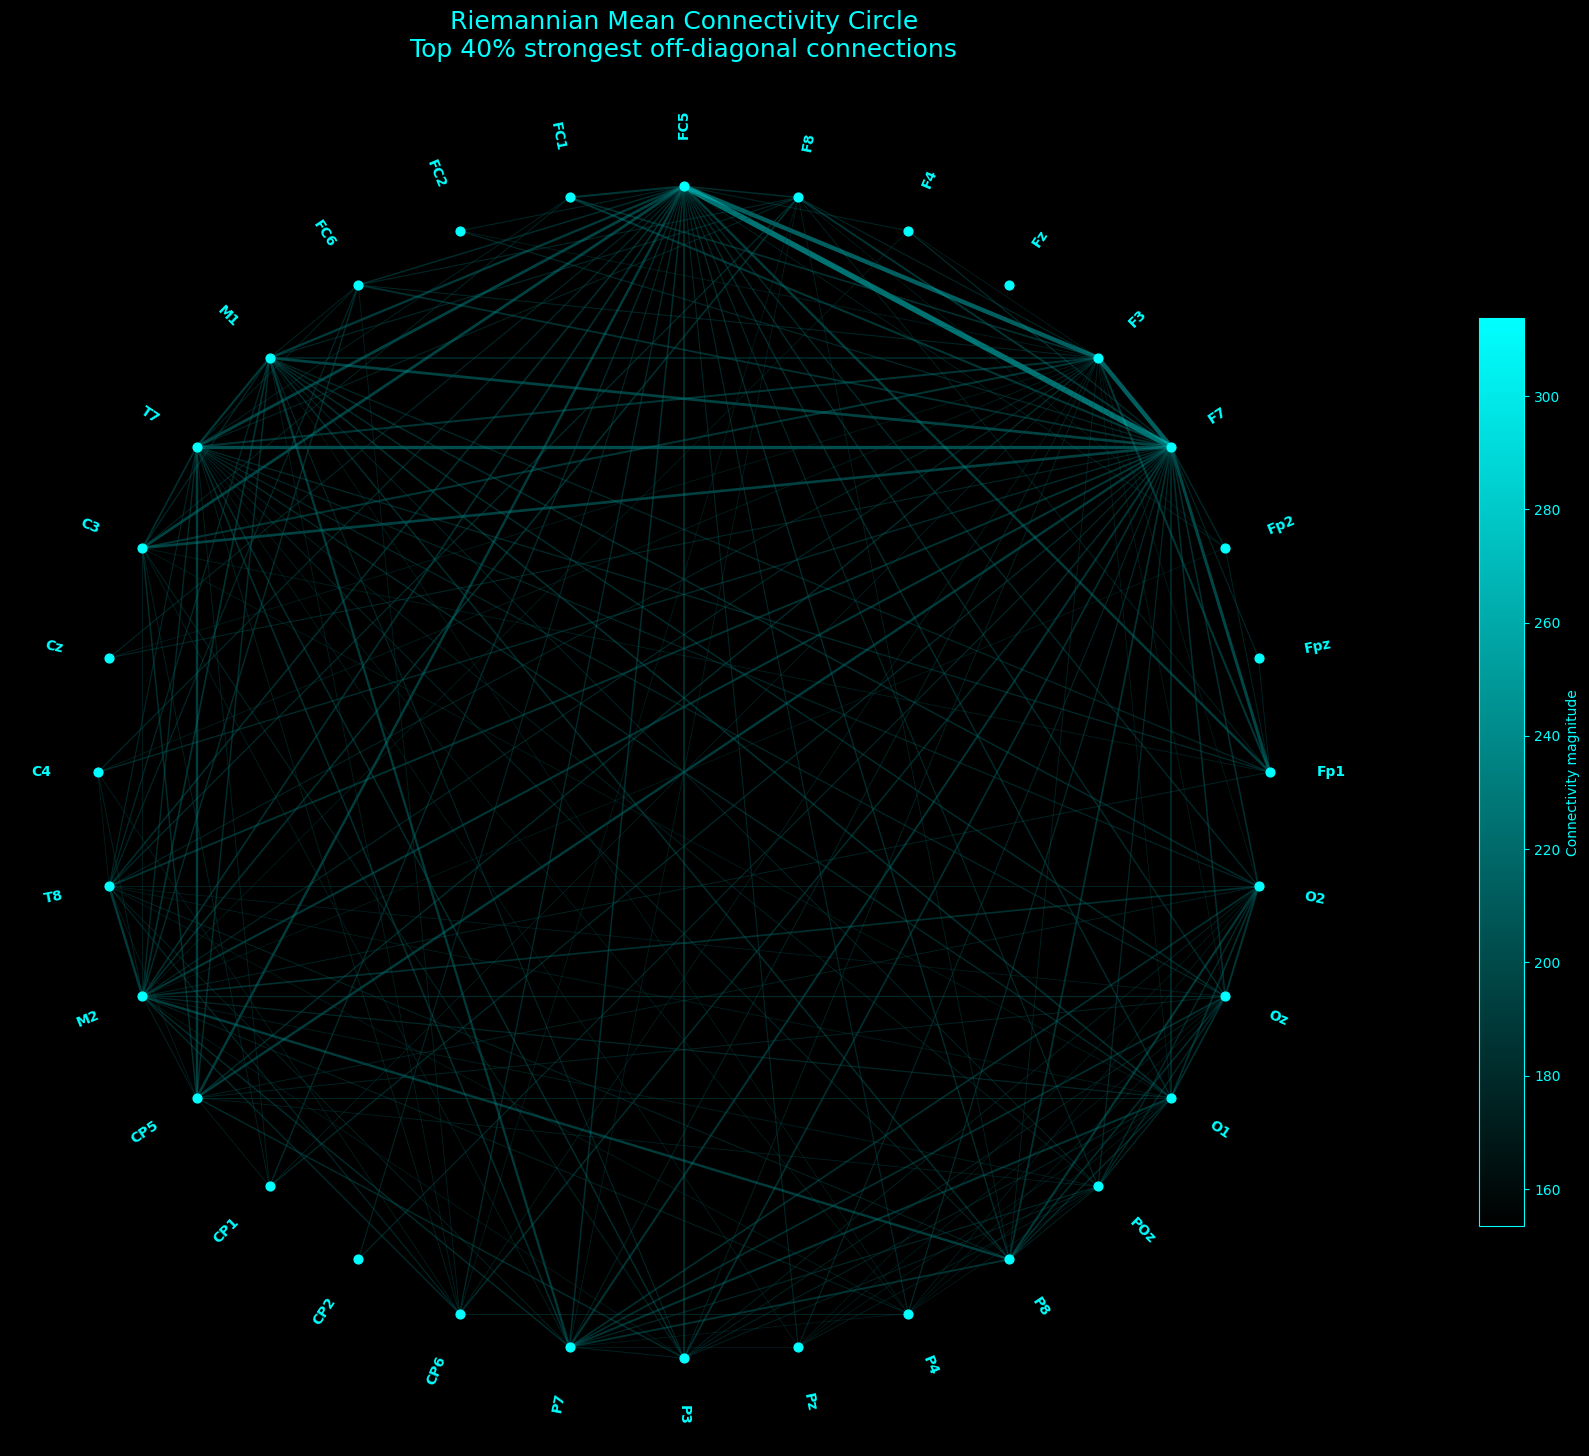

Saved connectivity circle plot to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_covariance_analysis/plots/riemannian_connectivity_circle.png


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
plots_dir = os.path.join(base_dir, "riemannian_covariance_analysis", "plots")
os.makedirs(plots_dir, exist_ok=True)

# Keep same plot style as your recent work
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
})

# -------------------------------------------------------
# INPUT CHECK
# -------------------------------------------------------
if "riemannian_mean" not in globals():
    raise ValueError("riemannian_mean is not defined. Run the Riemannian covariance block first.")

if "eeg_channel_names" not in globals():
    raise ValueError("eeg_channel_names is not defined.")

riemannian_mean = np.asarray(riemannian_mean, dtype=float)

if riemannian_mean.ndim != 2 or riemannian_mean.shape[0] != riemannian_mean.shape[1]:
    raise ValueError(f"riemannian_mean must be square, got shape {riemannian_mean.shape}")

if riemannian_mean.shape[0] != len(eeg_channel_names):
    raise ValueError(
        f"Mismatch: riemannian_mean has size {riemannian_mean.shape[0]} "
        f"but eeg_channel_names has length {len(eeg_channel_names)}"
    )

# -------------------------------------------------------
# PARAMETERS
# -------------------------------------------------------
# Percentile threshold on OFF-DIAGONAL connectivity magnitudes
percentile_threshold = 60

# Visual scaling
min_linewidth = 0.5
max_linewidth = 4.0
line_alpha = 0.45
label_radius = 1.08
node_radius = 1.0

# Cyan-style connectivity colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    "connectivity_cmap",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)],
    N=256
)

# -------------------------------------------------------
# PREP CONNECTIVITY
# -------------------------------------------------------
# Use magnitude of pairwise covariance-like connectivity for visualization
C = np.abs(riemannian_mean).copy()

# Ignore diagonal for thresholding and line plotting
n_channels = C.shape[0]
upper_i, upper_j = np.triu_indices(n_channels, k=1)
upper_vals = C[upper_i, upper_j]

if len(upper_vals) == 0:
    raise ValueError("No off-diagonal values found in riemannian_mean.")

threshold = np.percentile(upper_vals, percentile_threshold)

# Normalize only using off-diagonal values
vmin = np.min(upper_vals)
vmax = np.max(upper_vals)
if np.isclose(vmax, vmin):
    vmax = vmin + 1e-12

normalize = mcolors.Normalize(vmin=vmin, vmax=vmax)

# Channel angles on circle
angles = np.linspace(0, 2 * np.pi, n_channels, endpoint=False)

# -------------------------------------------------------
# FIGURE
# -------------------------------------------------------
fig = plt.figure(figsize=(16, 16), facecolor=BG)
ax = fig.add_subplot(111, polar=True)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Make the circle clean
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
ax.spines["polar"].set_visible(False)
ax.set_rlim(0, 1.15)

# -------------------------------------------------------
# PLOT CONNECTIONS
# -------------------------------------------------------
for i, j, strength in zip(upper_i, upper_j, upper_vals):
    if strength < threshold:
        continue

    # normalize line width above threshold
    frac = (strength - threshold) / (vmax - threshold + 1e-12)
    linewidth = min_linewidth + frac * (max_linewidth - min_linewidth)
    color = cmap(normalize(strength))

    ax.plot(
        [angles[i], angles[j]],
        [node_radius, node_radius],
        color=color,
        linewidth=linewidth,
        alpha=line_alpha,
        zorder=1
    )

# -------------------------------------------------------
# PLOT NODES
# -------------------------------------------------------
ax.scatter(
    angles,
    np.full(n_channels, node_radius),
    s=40,
    color=ACCENT,
    edgecolors=ACCENT,
    zorder=3
)

# -------------------------------------------------------
# LABELS
# -------------------------------------------------------
for angle, label in zip(angles, eeg_channel_names):
    angle_deg = np.degrees(angle)

    # Flip labels on left side for readability
    if 90 < angle_deg < 270:
        rotation = angle_deg + 180
        ha = "right"
    else:
        rotation = angle_deg
        ha = "left"

    ax.text(
        angle,
        label_radius,
        label,
        color=ACCENT,
        fontsize=10,
        fontweight="bold",
        ha=ha,
        va="center",
        rotation=rotation,
        rotation_mode="anchor",
        zorder=4
    )

# -------------------------------------------------------
# TITLE
# -------------------------------------------------------
ax.set_title(
    f"Riemannian Mean Connectivity Circle\nTop {100 - percentile_threshold:.0f}% strongest off-diagonal connections",
    color=ACCENT,
    fontsize=18,
    pad=30
)

# -------------------------------------------------------
# COLORBAR
# -------------------------------------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=normalize)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, pad=0.08, fraction=0.03)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.yaxis.label.set_color(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for tick in cbar.ax.get_yticklabels():
    tick.set_color(ACCENT)
cbar.set_label("Connectivity magnitude", color=ACCENT)

# -------------------------------------------------------
# SAVE + SHOW
# -------------------------------------------------------
save_path = os.path.join(plots_dir, "riemannian_connectivity_circle.png")
plt.tight_layout()
plt.savefig(save_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved connectivity circle plot to: {save_path}")

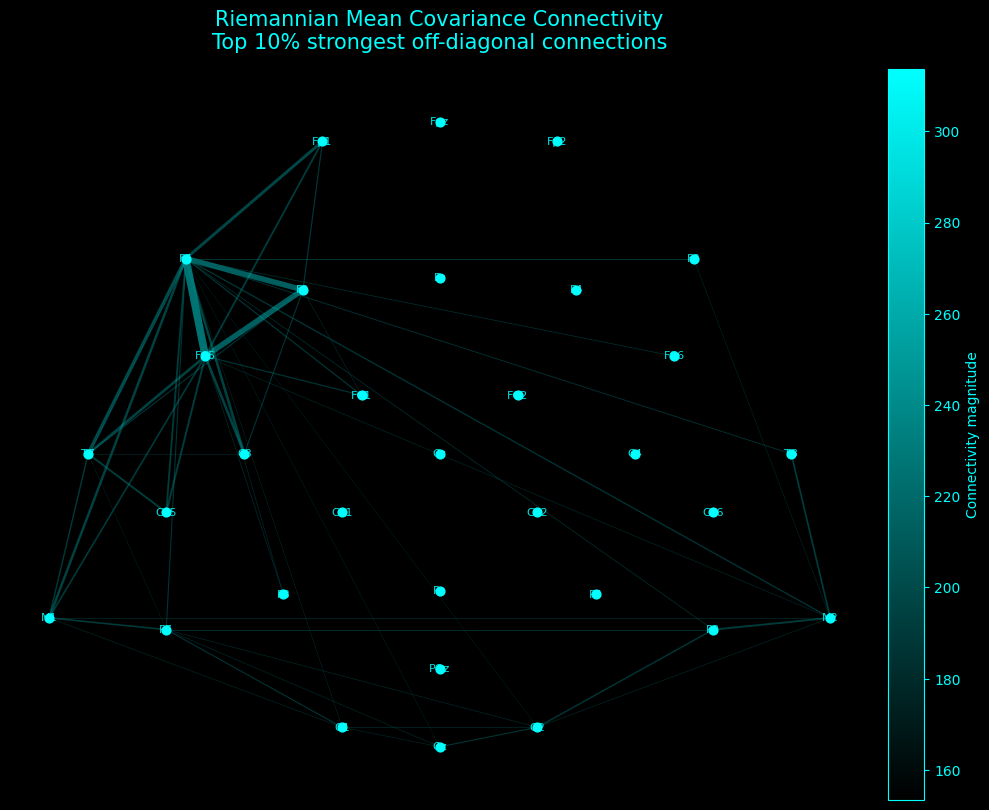

Saved topographic connectivity plot to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_covariance_analysis/plots/riemannian_connectivity_topography.png


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
plots_dir = os.path.join(base_dir, "riemannian_covariance_analysis", "plots")
os.makedirs(plots_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
})

# -------------------------------------------------------
# INPUT CHECK
# -------------------------------------------------------
if "riemannian_mean" not in globals():
    raise ValueError("riemannian_mean is not defined. Run the Riemannian covariance block first.")

if "eeg_channel_names" not in globals():
    raise ValueError("eeg_channel_names is not defined.")

riemannian_mean = np.asarray(riemannian_mean, dtype=float)

if riemannian_mean.ndim != 2 or riemannian_mean.shape[0] != riemannian_mean.shape[1]:
    raise ValueError(f"riemannian_mean must be square, got shape {riemannian_mean.shape}")

if riemannian_mean.shape[0] != len(eeg_channel_names):
    raise ValueError(
        f"Mismatch: riemannian_mean has size {riemannian_mean.shape[0]} "
        f"but eeg_channel_names has length {len(eeg_channel_names)}"
    )

# -------------------------------------------------------
# CHANNEL COORDINATES
# -------------------------------------------------------
channel_coords = {
    'Fp1': (-0.3, 0.95), 'Fpz': (0.0, 1.0), 'Fp2': (0.3, 0.95),
    'F7': (-0.65, 0.65), 'F3': (-0.35, 0.57), 'Fz': (0.0, 0.6), 'F4': (0.35, 0.57), 'F8': (0.65, 0.65),
    'FC5': (-0.6, 0.4), 'FC1': (-0.2, 0.3), 'FC2': (0.2, 0.3), 'FC6': (0.6, 0.4),
    'T7': (-0.9, 0.15), 'C3': (-0.5, 0.15), 'Cz': (0.0, 0.15), 'C4': (0.5, 0.15), 'T8': (0.9, 0.15),
    'CP5': (-0.7, 0.0), 'CP1': (-0.25, 0.0), 'CP2': (0.25, 0.0), 'CP6': (0.7, 0.0),
    'P7': (-0.7, -0.3), 'P3': (-0.4, -0.21), 'Pz': (0.0, -0.2), 'P4': (0.4, -0.21), 'P8': (0.7, -0.3),
    'POz': (0.0, -0.4),
    'O1': (-0.25, -0.55), 'Oz': (0.0, -0.6), 'O2': (0.25, -0.55),
    'M1': (-1.0, -0.27), 'M2': (1.0, -0.27)
}

# -------------------------------------------------------
# PARAMETERS
# -------------------------------------------------------
# Keep only strongest off-diagonal connections
percentile_threshold = 90

min_linewidth = 0.25
max_linewidth = 5.5
line_alpha = 0.45
node_size = 40
label_fontsize = 8

# Colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    "connectivity_cmap",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)],
    N=256
)

# -------------------------------------------------------
# PREP CONNECTIVITY
# -------------------------------------------------------
C = np.abs(riemannian_mean).copy()

# Use only channel pairs whose coordinates exist
valid_indices = [i for i, ch in enumerate(eeg_channel_names) if ch in channel_coords]
valid_names = [eeg_channel_names[i] for i in valid_indices]

if len(valid_indices) < 2:
    raise ValueError("Not enough valid channels with defined coordinates.")

# Build list of valid off-diagonal pair strengths
pair_info = []
for a, i in enumerate(valid_indices):
    for b, j in enumerate(valid_indices):
        if i < j:
            pair_info.append((i, j, eeg_channel_names[i], eeg_channel_names[j], C[i, j]))

pair_strengths = np.array([p[4] for p in pair_info], dtype=float)

if len(pair_strengths) == 0:
    raise ValueError("No valid channel pairs available for plotting.")

threshold = np.percentile(pair_strengths, percentile_threshold)

vmin = np.min(pair_strengths)
vmax = np.max(pair_strengths)
if np.isclose(vmax, vmin):
    vmax = vmin + 1e-12

normalize = mcolors.Normalize(vmin=vmin, vmax=vmax)

# -------------------------------------------------------
# FIGURE
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# -------------------------------------------------------
# PLOT CONNECTIONS
# -------------------------------------------------------
for i, j, ch1, ch2, strength in pair_info:
    if strength < threshold:
        continue

    frac = (strength - threshold) / (vmax - threshold + 1e-12)
    linewidth = min_linewidth + frac * (max_linewidth - min_linewidth)
    color = cmap(normalize(strength))

    x1, y1 = channel_coords[ch1]
    x2, y2 = channel_coords[ch2]

    ax.plot(
        [x1, x2],
        [y1, y2],
        alpha=line_alpha,
        linewidth=linewidth,
        color=color,
        linestyle='-',
        zorder=1
    )

# -------------------------------------------------------
# PLOT NODES
# -------------------------------------------------------
for ch in valid_names:
    x, y = channel_coords[ch]
    ax.scatter(
        x, y,
        s=node_size,
        color=ACCENT,
        edgecolors=ACCENT,
        zorder=3
    )

# -------------------------------------------------------
# PLOT LABELS
# -------------------------------------------------------
for ch in valid_names:
    x, y = channel_coords[ch]
    ax.text(
        x, y,
        ch,
        ha='center',
        va='center',
        color=ACCENT,
        fontsize=label_fontsize,
        alpha=0.9,
        zorder=4
    )

# -------------------------------------------------------
# AXIS / TITLE
# -------------------------------------------------------
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(
    f"Riemannian Mean Covariance Connectivity\nTop {100 - percentile_threshold:.0f}% strongest off-diagonal connections",
    color=ACCENT,
    size=15,
    pad=30
)

# -------------------------------------------------------
# COLORBAR
# -------------------------------------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=normalize)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, pad=0.02, fraction=0.04)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.yaxis.label.set_color(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for tick in cbar.ax.get_yticklabels():
    tick.set_color(ACCENT)
cbar.set_label("Connectivity magnitude", color=ACCENT)

# -------------------------------------------------------
# SAVE + SHOW
# -------------------------------------------------------
save_path = os.path.join(plots_dir, "riemannian_connectivity_topography.png")
plt.tight_layout()
plt.savefig(save_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved topographic connectivity plot to: {save_path}")

### Riemann Curvature Tensor on the SPD Covariance Manifold

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis computes a reduced <strong>Riemann curvature tensor</strong> for the manifold of symmetric positive definite (SPD) covariance matrices derived from EEG epochs. The covariance matrices are first summarized by their affine-invariant Riemannian mean, and then the local geometry around that mean is studied through curvature. Because the full tangent space is very large, the code projects the problem into a <strong>data-driven reduced tangent basis</strong> obtained from the dominant singular vectors of the EEG covariance variation.</p>
        <h2>Geometric Setting</h2>
        <p>The covariance matrices live on the SPD manifold, not in ordinary Euclidean space. The code uses the <strong>affine-invariant Riemannian metric</strong>, which is standard for covariance geometry because it respects the intrinsic structure of SPD matrices.</p>
        <p><strong>Whitened tangent coordinates:</strong></p>
        \[
        X_i = \log\!\left(P^{-1/2} C_i P^{-1/2}\right)
        \]
        <p>where \(C_i\) is the covariance matrix of epoch \(i\), and \(P\) is the Riemannian mean. This maps each covariance matrix into the tangent space at the mean in identity coordinates.</p>
        <h2>Reduced Tangent Basis</h2>
        <p>The tangent vectors are vectorized using a symmetric-matrix encoding that preserves the Frobenius inner product. After centering these tangent vectors, singular value decomposition (SVD) is applied to identify the dominant modes of covariance variation.</p>
        <p><strong>SVD:</strong></p>
        \[
        T = U \Sigma V^\top
        \]
        <p>The first \(k\) right-singular vectors define the reduced tangent basis used for curvature calculations. This makes the tensor tractable while preserving the most meaningful directions of variation in the EEG covariance data.</p>
        <h2>Riemann Curvature Tensor</h2>
        <p>For the SPD manifold with the affine-invariant metric, the curvature at the identity takes a closed form in terms of matrix commutators.</p>
        <p><strong>Curvature operator:</strong></p>
        \[
        R(X,Y)Z = -\frac{1}{4}\, [[X,Y],Z]
        \]
        <p>where the commutator is</p>
        \[
        [X,Y] = XY - YX
        \]
        <p>The reduced tensor components are then computed in the data-driven basis \(\{B_a\}\):</p>
        \[
        R_{abcd} = \langle R(B_a,B_b)B_c,\; B_d\rangle
        \]
        <p>with the Frobenius inner product</p>
        \[
        \langle A,B\rangle = \mathrm{tr}(A^\top B)
        \]
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Sectional Curvature</h2>
        <p>The code also computes the sectional curvature between pairs of orthonormal tangent directions. This tells us how sharply the SPD covariance manifold bends in each two-dimensional plane of the reduced tangent space.</p>
        <p><strong>Sectional curvature:</strong></p>
        \[
        K(X,Y) = \langle R(X,Y)Y,\; X\rangle
        \]
        <p>For the affine-invariant SPD manifold, sectional curvature is typically non-positive, so negative values indicate saddle-like intrinsic geometry. This is useful for understanding the local organization of EEG covariance states.</p>
        <h2>Implementation Details</h2>
        <p>The code follows these steps:</p>
        <ul>
            <li>Load the previously computed EEG covariance matrices and their Riemannian mean.</li>
            <li>Map each covariance matrix into the tangent space at the mean using the matrix logarithm.</li>
            <li>Vectorize and center the tangent vectors.</li>
            <li>Use SVD to obtain the top \(k\) reduced tangent directions.</li>
            <li>Compute the reduced Riemann curvature tensor \(R_{abcd}\).</li>
            <li>Compute the sectional curvature matrix \(K_{ab}\).</li>
            <li>Summarize and visualize the curvature structure.</li>
        </ul>
        <h2>Outputs and Visualizations</h2>
        <p>The code generates several outputs:</p>
        <ul>
            <li><strong>Reduced curvature tensor</strong> saved in an NPZ file.</li>
            <li><strong>Sectional curvature heatmap</strong> showing curvature between basis directions.</li>
            <li><strong>Mean sectional curvature bar plot</strong> summarizing how curved each dominant direction is on average.</li>
            <li><strong>SVD singular values plot</strong> showing how much covariance variation is captured by each reduced tangent direction.</li>
            <li><strong>CSV and TXT summaries</strong> describing global curvature statistics.</li>
        </ul>
        <h2>Interpretation</h2>
        <p>This analysis does not just measure covariance strength; it measures the <strong>intrinsic geometry of covariance variation</strong>. If the reduced tangent basis shows strongly negative sectional curvature, that means nearby EEG covariance states diverge in a saddle-like manner on the SPD manifold. If the curvature is weak, the local manifold is closer to flat in those directions.</p>
        <h2>Conclusion</h2>
        <p>This methodology provides a geometric description of EEG covariance dynamics by computing a reduced Riemann curvature tensor on the SPD manifold. Instead of treating covariance matrices as ordinary Euclidean points, it studies them as points on a curved manifold and quantifies how that manifold bends around the Riemannian mean. This gives a deeper characterization of the structure of EEG covariance organization than simple averaging alone.</p>
    </div>
</div>

Loaded covariance tensor: (106, 32, 32)
Loaded Riemannian mean: (32, 32)
Full tangent dimension: 528
Using reduced tangent basis dimension: 8

Reduced-basis curvature summary:
   basis_index  svd_singular_value  self_norm  \
0            0           15.132345        1.0   
1            1            9.509011        1.0   
2            2            7.507333        1.0   
3            3            6.012405        1.0   
4            4            5.661071        1.0   
5            5            5.268066        1.0   
6            6            5.090050        1.0   
7            7            4.991946        1.0   

   mean_sectional_curvature_vs_others  min_sectional_curvature_vs_others  \
0                           -0.012562                          -0.024685   
1                           -0.005284                          -0.006262   
2                           -0.010631                          -0.017261   
3                           -0.013264                          -0.022162   
4 

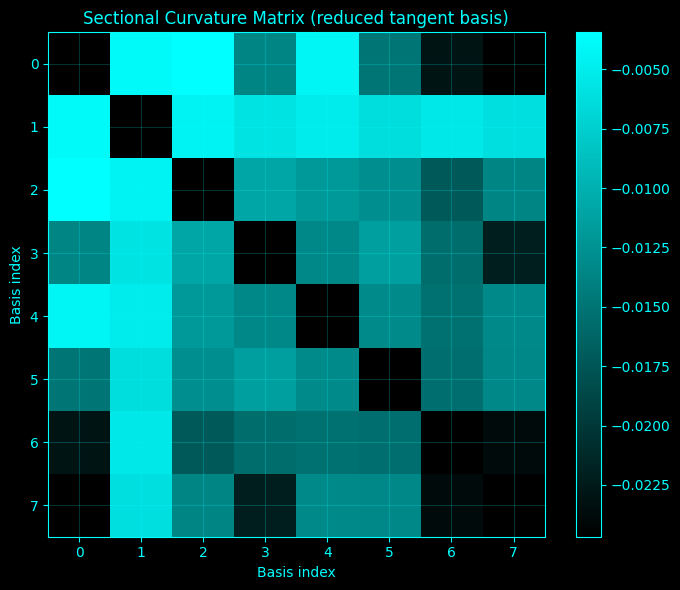

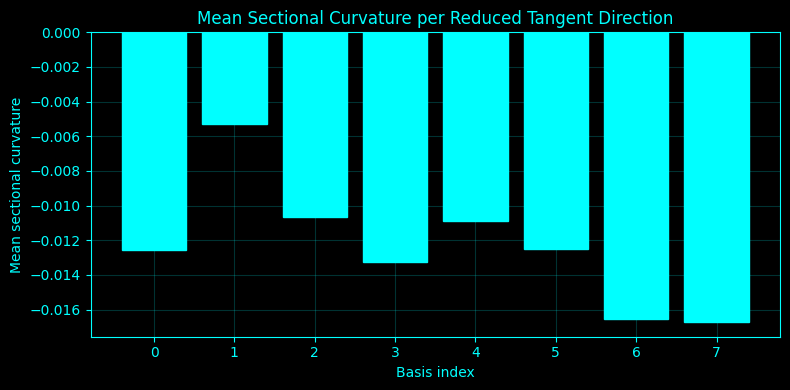

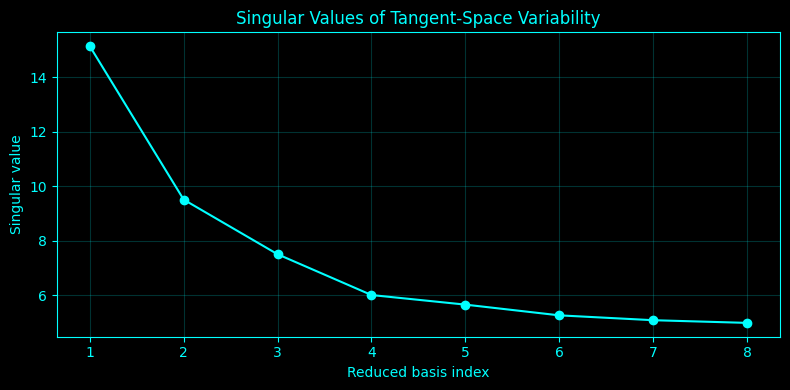


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/riemann_curvature_tensor_analysis
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/riemann_curvature_tensor_analysis/riemann_curvature_tensor_results.npz
Saved CSV: /home/a/projects/Complete-Neural-Signal-Analysis/riemann_curvature_tensor_analysis/riemann_curvature_tensor_summary.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/riemann_curvature_tensor_analysis/riemann_curvature_tensor_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/riemann_curvature_tensor_analysis/plots


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
riem_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
riem_npz_path = os.path.join(riem_dir, "riemannian_covariance_results.npz")

out_dir = os.path.join(base_dir, "riemann_curvature_tensor_analysis")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Reduced tangent subspace dimension
top_k = 8

# Numerical floor
eps = 1e-12

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD HELPERS
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def sqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.sqrt(w)) @ V.T

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.log(w)) @ V.T

def fro_inner(A, B):
    return float(np.sum(A * B))

def fro_norm(A):
    return float(np.sqrt(max(fro_inner(A, A), 0.0)))

def commutator(A, B):
    return A @ B - B @ A

# -------------------------------------------------------
# SYMMETRIC VECTORIZATION (ISOMETRIC FOR FROBENIUS NORM)
# -------------------------------------------------------
def symmat_to_vec(S):
    """
    Vectorize a symmetric matrix with sqrt(2) weighting on off-diagonals
    so Euclidean inner product matches Frobenius inner product.
    """
    S = symmetrize(np.asarray(S, dtype=float))
    n = S.shape[0]
    vals = []
    for i in range(n):
        vals.append(S[i, i])
    for i in range(n):
        for j in range(i + 1, n):
            vals.append(np.sqrt(2.0) * S[i, j])
    return np.asarray(vals, dtype=float)

def vec_to_symmat(v, n):
    S = np.zeros((n, n), dtype=float)
    idx = 0
    for i in range(n):
        S[i, i] = v[idx]
        idx += 1
    for i in range(n):
        for j in range(i + 1, n):
            val = v[idx] / np.sqrt(2.0)
            S[i, j] = val
            S[j, i] = val
            idx += 1
    return S

# -------------------------------------------------------
# LOG MAP TO IDENTITY COORDINATES
# -------------------------------------------------------
def whiten_to_identity_tangent(C, P_invsqrt):
    """
    Identity-coordinate tangent:
      X = log(P^{-1/2} C P^{-1/2})
    """
    inner = P_invsqrt @ C @ P_invsqrt
    return symmetrize(logm_spd(inner))

# -------------------------------------------------------
# AFFINE-INVARIANT CURVATURE ON SPD
# -------------------------------------------------------
def riemann_curvature_at_identity(X, Y, Z):
    """
    For SPD manifold with affine-invariant metric:
        R(X, Y)Z = -1/4 [[X, Y], Z]
    at the identity, where X,Y,Z are symmetric tangent matrices.
    """
    return -0.25 * commutator(commutator(X, Y), Z)

def sectional_curvature_orthonormal(X, Y):
    """
    For orthonormal X,Y in identity coordinates:
        K(X,Y) = <R(X,Y)Y, X>
    """
    Rxyy = riemann_curvature_at_identity(X, Y, Y)
    return fro_inner(Rxyy, X)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
if not os.path.exists(riem_npz_path):
    raise FileNotFoundError(
        f"Missing {riem_npz_path}. Run the Riemannian covariance mean code first."
    )

data = np.load(riem_npz_path, allow_pickle=True)
cov_matrices = np.asarray(data["cov_matrices"], dtype=float)
P = np.asarray(data["riemannian_mean"], dtype=float)

n_epochs, n_channels, _ = cov_matrices.shape
print(f"Loaded covariance tensor: {cov_matrices.shape}")
print(f"Loaded Riemannian mean: {P.shape}")

# -------------------------------------------------------
# BUILD DATA-DRIVEN TANGENT SUBSPACE
# -------------------------------------------------------
P_invsqrt = invsqrtm_spd(P)

# Tangent coordinates at identity
tangent_vecs = []
for i in range(n_epochs):
    Xi = whiten_to_identity_tangent(cov_matrices[i], P_invsqrt)
    tangent_vecs.append(symmat_to_vec(Xi))

T = np.stack(tangent_vecs, axis=0)   # shape: (epochs, tangent_dim_full)
T = T - np.mean(T, axis=0, keepdims=True)

full_tangent_dim = T.shape[1]
k_eff = min(top_k, n_epochs, full_tangent_dim)

# SVD for orthonormal basis directions
U, Svals, Vt = np.linalg.svd(T, full_matrices=False)
basis_vecs = Vt[:k_eff]  # rows are orthonormal in Euclidean coords

basis_mats = [vec_to_symmat(basis_vecs[i], n_channels) for i in range(k_eff)]

print(f"Full tangent dimension: {full_tangent_dim}")
print(f"Using reduced tangent basis dimension: {k_eff}")

# -------------------------------------------------------
# CURVATURE TENSOR IN REDUCED BASIS
# -------------------------------------------------------
# Tensor components:
#   R[a,b,c,d] = < R(B_a, B_b) B_c , B_d >
R_tensor = np.zeros((k_eff, k_eff, k_eff, k_eff), dtype=float)

for a in range(k_eff):
    for b in range(k_eff):
        for c in range(k_eff):
            Rab_c = riemann_curvature_at_identity(basis_mats[a], basis_mats[b], basis_mats[c])
            for d in range(k_eff):
                R_tensor[a, b, c, d] = fro_inner(Rab_c, basis_mats[d])

# -------------------------------------------------------
# SECTIONAL CURVATURE MATRIX
# -------------------------------------------------------
K_sec = np.full((k_eff, k_eff), np.nan, dtype=float)

for a in range(k_eff):
    for b in range(k_eff):
        if a == b:
            K_sec[a, b] = np.nan
        else:
            K_sec[a, b] = sectional_curvature_orthonormal(basis_mats[a], basis_mats[b])

# -------------------------------------------------------
# SUMMARY TABLE
# -------------------------------------------------------
rows = []
for a in range(k_eff):
    row = {
        "basis_index": a,
        "svd_singular_value": float(Svals[a]) if a < len(Svals) else np.nan,
        "self_norm": fro_norm(basis_mats[a]),
        "mean_sectional_curvature_vs_others": float(np.nanmean(K_sec[a])),
        "min_sectional_curvature_vs_others": float(np.nanmin(K_sec[a])),
        "max_sectional_curvature_vs_others": float(np.nanmax(K_sec[a])),
    }
    rows.append(row)

summary_df = pd.DataFrame(rows)

global_summary = {
    "k_eff": k_eff,
    "n_epochs": n_epochs,
    "n_channels": n_channels,
    "full_tangent_dim": full_tangent_dim,
    "mean_sectional_curvature": float(np.nanmean(K_sec)),
    "min_sectional_curvature": float(np.nanmin(K_sec)),
    "max_sectional_curvature": float(np.nanmax(K_sec)),
    "fraction_negative_sectional_curvature": float(np.mean(K_sec[np.isfinite(K_sec)] < 0)),
}

print("\nReduced-basis curvature summary:")
print(summary_df)
print("\nGlobal summary:")
for k, v in global_summary.items():
    print(f"{k}: {v}")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "riemann_curvature_tensor_results.npz")
np.savez(
    npz_path,
    riemannian_mean=P,
    cov_matrices_shape=np.array(cov_matrices.shape),
    basis_vectors=basis_vecs,
    basis_matrices=np.stack(basis_mats, axis=0),
    singular_values=Svals[:k_eff],
    R_tensor=R_tensor,
    sectional_curvature=K_sec,
    top_k_used=k_eff
)

summary_csv = os.path.join(out_dir, "riemann_curvature_tensor_summary.csv")
summary_df.to_csv(summary_csv, index=False)

global_txt = os.path.join(out_dir, "riemann_curvature_tensor_summary.txt")
with open(global_txt, "w") as f:
    f.write("Riemann Curvature Tensor on the SPD Covariance Manifold\n")
    f.write("=====================================================\n\n")
    f.write(f"Source NPZ: {riem_npz_path}\n")
    f.write(f"Epochs: {n_epochs}\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Full tangent dimension: {full_tangent_dim}\n")
    f.write(f"Reduced basis dimension: {k_eff}\n\n")
    for k, v in global_summary.items():
        f.write(f"{k}: {v}\n")

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: SECTIONAL CURVATURE HEATMAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
style_ax(ax)

# show magnitude but keep signs in text summary
im = ax.imshow(K_sec, cmap=custom_cmap, aspect="auto")
ax.set_title("Sectional Curvature Matrix (reduced tangent basis)")
ax.set_xlabel("Basis index")
ax.set_ylabel("Basis index")
ax.set_xticks(np.arange(k_eff))
ax.set_yticks(np.arange(k_eff))
ax.set_xticklabels(np.arange(k_eff), color=ACCENT)
ax.set_yticklabels(np.arange(k_eff), color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

heatmap_path = os.path.join(plots_dir, "sectional_curvature_heatmap.png")
plt.tight_layout()
plt.savefig(heatmap_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: MEAN SECTIONAL CURVATURE PER BASIS DIRECTION
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    np.arange(k_eff),
    summary_df["mean_sectional_curvature_vs_others"].values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Mean Sectional Curvature per Reduced Tangent Direction")
ax.set_xlabel("Basis index")
ax.set_ylabel("Mean sectional curvature")
ax.set_xticks(np.arange(k_eff))
ax.set_xticklabels(np.arange(k_eff), color=ACCENT)

bar_path = os.path.join(plots_dir, "mean_sectional_curvature_per_basis.png")
plt.tight_layout()
plt.savefig(bar_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: SINGULAR VALUES OF TANGENT VARIATION
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.plot(
    np.arange(1, k_eff + 1),
    Svals[:k_eff],
    marker="o",
    color=ACCENT
)
ax.set_title("Singular Values of Tangent-Space Variability")
ax.set_xlabel("Reduced basis index")
ax.set_ylabel("Singular value")

sv_path = os.path.join(plots_dir, "tangent_svd_singular_values.png")
plt.tight_layout()
plt.savefig(sv_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved CSV: {summary_csv}")
print(f"Saved TXT: {global_txt}")
print(f"Saved plots to: {plots_dir}")

### Riemannian Distance Landscape Across EEG Covariance Epochs

Loaded covariance matrices: (106, 32, 32)
Loaded Riemannian mean: (32, 32)
Segment: [814.571, 921.515] sec
Window size: 1.0 sec

Global Riemannian distance summary:
n_epochs: 106
n_channels: 32
segment_start_sec: 814.571
segment_end_sec: 921.515
window_size_sec: 1.0
mean_distance: 3.474116426816656
std_distance: 0.8659323020733664
min_distance: 2.580624259571224
max_distance: 8.08029750296199
median_distance: 3.238975676518984
q10_distance: 2.869886046598256
q90_distance: 4.080990224374581
mean_speed_abs: 0.6507877701351907
max_speed_abs: 4.645610548984998
farthest_epoch_index: 4
nearest_epoch_index: 11


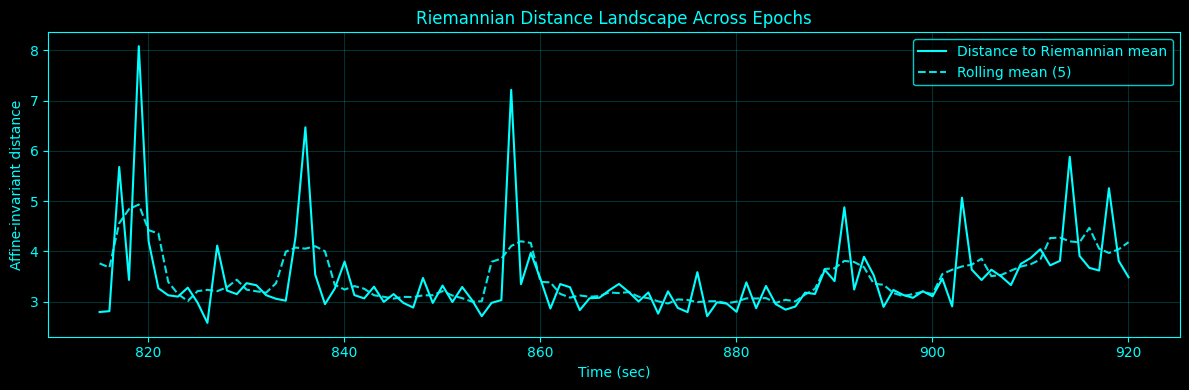

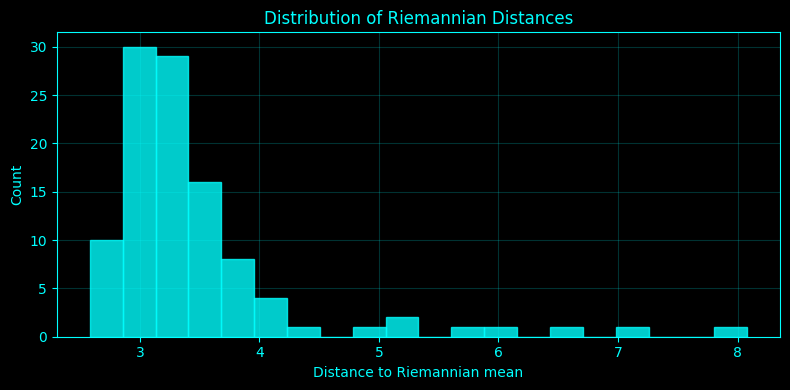

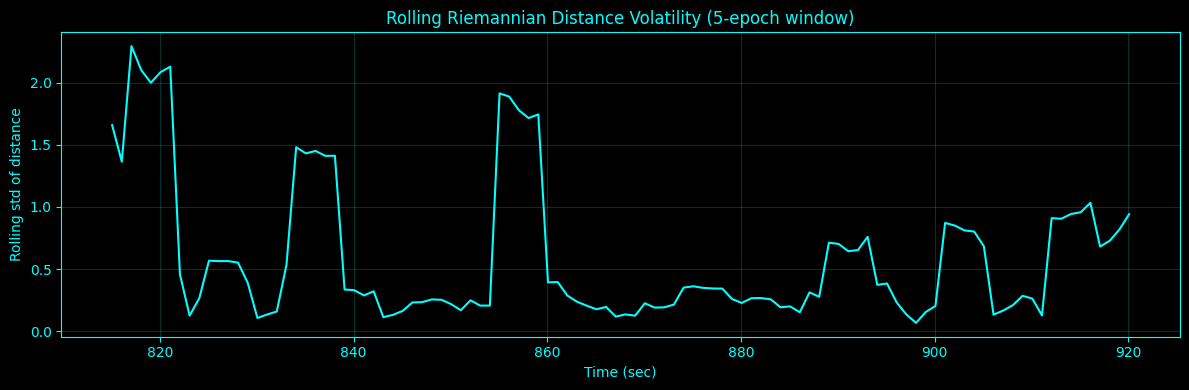

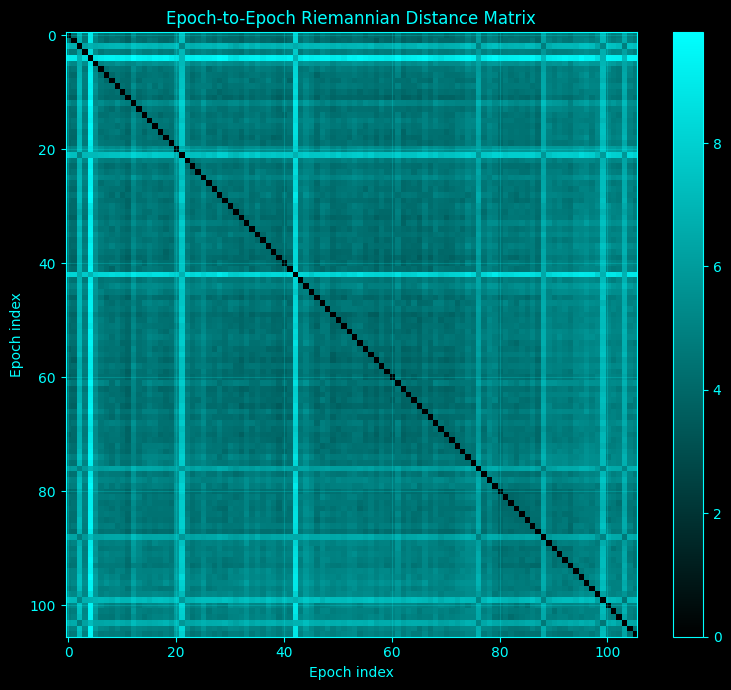

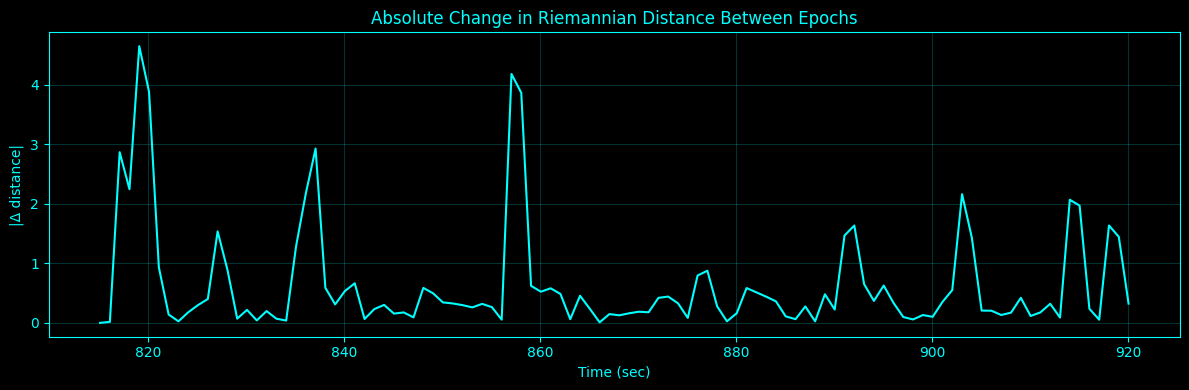


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_distance_landscape
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_distance_landscape/riemannian_distance_landscape_results.npz
Saved CSV: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_distance_landscape/riemannian_distance_landscape_summary.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_distance_landscape/riemannian_distance_landscape_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_distance_landscape/plots


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
riem_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
riem_npz_path = os.path.join(riem_dir, "riemannian_covariance_results.npz")

out_dir = os.path.join(base_dir, "riemannian_distance_landscape")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"

rolling_window = 5   # epochs
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD HELPERS
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.log(w)) @ V.T

def affine_invariant_distance(C, P, P_invsqrt=None):
    """
    d_R(C, P) = || log(P^{-1/2} C P^{-1/2}) ||_F
    """
    C = symmetrize(np.asarray(C, dtype=float))
    P = symmetrize(np.asarray(P, dtype=float))

    if P_invsqrt is None:
        P_invsqrt = invsqrtm_spd(P)

    inner = P_invsqrt @ C @ P_invsqrt
    L = logm_spd(inner)
    return float(np.sqrt(np.sum(L * L)))

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
if not os.path.exists(riem_npz_path):
    raise FileNotFoundError(
        f"Missing {riem_npz_path}. Run the Riemannian covariance mean block first."
    )

data = np.load(riem_npz_path, allow_pickle=True)

cov_matrices = np.asarray(data["cov_matrices"], dtype=float)
riemannian_mean = np.asarray(data["riemannian_mean"], dtype=float)

start_time = float(data["start_time"])
end_time = float(data["end_time"])
sampling_rate = float(data["sampling_rate"])
window_size_sec = float(data["window_size_sec"])

n_epochs, n_channels, _ = cov_matrices.shape

print(f"Loaded covariance matrices: {cov_matrices.shape}")
print(f"Loaded Riemannian mean: {riemannian_mean.shape}")
print(f"Segment: [{start_time}, {end_time}] sec")
print(f"Window size: {window_size_sec} sec")

# -------------------------------------------------------
# DISTANCE TO RIEMANNIAN MEAN
# -------------------------------------------------------
P_invsqrt = invsqrtm_spd(riemannian_mean)

distances = np.zeros(n_epochs, dtype=float)
for i in range(n_epochs):
    distances[i] = affine_invariant_distance(cov_matrices[i], riemannian_mean, P_invsqrt=P_invsqrt)

# Epoch timing
epoch_index = np.arange(n_epochs)
epoch_start_time = start_time + epoch_index * window_size_sec
epoch_center_time = epoch_start_time + 0.5 * window_size_sec

# Basic derived quantities
distance_z = (distances - np.mean(distances)) / (np.std(distances) + 1e-12)
distance_delta = np.diff(distances, prepend=distances[0])
distance_speed = np.abs(distance_delta)

# Rolling stats via pandas for convenience
dist_s = pd.Series(distances)
rolling_mean = dist_s.rolling(rolling_window, center=True, min_periods=1).mean().to_numpy()
rolling_std = dist_s.rolling(rolling_window, center=True, min_periods=1).std().fillna(0.0).to_numpy()

# Pairwise epoch-to-epoch Riemannian distance matrix
epoch_distance_matrix = np.zeros((n_epochs, n_epochs), dtype=float)
for i in range(n_epochs):
    epoch_distance_matrix[i, i] = 0.0
    for j in range(i + 1, n_epochs):
        dij = affine_invariant_distance(cov_matrices[i], cov_matrices[j])
        epoch_distance_matrix[i, j] = dij
        epoch_distance_matrix[j, i] = dij

# -------------------------------------------------------
# SUMMARY TABLE
# -------------------------------------------------------
summary_df = pd.DataFrame({
    "epoch_index": epoch_index,
    "epoch_start_time_sec": epoch_start_time,
    "epoch_center_time_sec": epoch_center_time,
    "distance_to_riemannian_mean": distances,
    "distance_zscore": distance_z,
    "distance_delta": distance_delta,
    "distance_speed_abs": distance_speed,
    "rolling_mean_distance": rolling_mean,
    "rolling_std_distance": rolling_std,
})

global_summary = {
    "n_epochs": int(n_epochs),
    "n_channels": int(n_channels),
    "segment_start_sec": start_time,
    "segment_end_sec": end_time,
    "window_size_sec": window_size_sec,
    "mean_distance": float(np.mean(distances)),
    "std_distance": float(np.std(distances)),
    "min_distance": float(np.min(distances)),
    "max_distance": float(np.max(distances)),
    "median_distance": float(np.median(distances)),
    "q10_distance": float(np.quantile(distances, 0.10)),
    "q90_distance": float(np.quantile(distances, 0.90)),
    "mean_speed_abs": float(np.mean(distance_speed)),
    "max_speed_abs": float(np.max(distance_speed)),
    "farthest_epoch_index": int(np.argmax(distances)),
    "nearest_epoch_index": int(np.argmin(distances)),
}

print("\nGlobal Riemannian distance summary:")
for k, v in global_summary.items():
    print(f"{k}: {v}")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "riemannian_distance_landscape_results.npz")
np.savez(
    npz_path,
    cov_matrices_shape=np.array(cov_matrices.shape),
    riemannian_mean=riemannian_mean,
    distances=distances,
    distance_z=distance_z,
    distance_delta=distance_delta,
    distance_speed=distance_speed,
    rolling_mean=rolling_mean,
    rolling_std=rolling_std,
    epoch_distance_matrix=epoch_distance_matrix,
    epoch_start_time=epoch_start_time,
    epoch_center_time=epoch_center_time,
    window_size_sec=window_size_sec,
    start_time=start_time,
    end_time=end_time,
)

summary_csv = os.path.join(out_dir, "riemannian_distance_landscape_summary.csv")
summary_df.to_csv(summary_csv, index=False)

summary_txt = os.path.join(out_dir, "riemannian_distance_landscape_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Riemannian Distance Landscape Across Epochs\n")
    f.write("=========================================\n\n")
    f.write(f"Source NPZ: {riem_npz_path}\n")
    f.write(f"Epochs: {n_epochs}\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Window size: {window_size_sec} sec\n\n")
    for k, v in global_summary.items():
        f.write(f"{k}: {v}\n")

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: DISTANCE LANDSCAPE OVER TIME
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.plot(epoch_center_time, distances, color=ACCENT, linewidth=1.5, label="Distance to Riemannian mean")
ax.plot(epoch_center_time, rolling_mean, color=ACCENT, linestyle="--", linewidth=1.5, alpha=0.9, label=f"Rolling mean ({rolling_window})")

ax.set_title("Riemannian Distance Landscape Across Epochs")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Affine-invariant distance")
ax.legend()

plot1_path = os.path.join(plots_dir, "distance_landscape_over_time.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: HISTOGRAM OF DISTANCES
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.hist(distances, bins=20, color=ACCENT, edgecolor=ACCENT, alpha=0.8)
ax.set_title("Distribution of Riemannian Distances")
ax.set_xlabel("Distance to Riemannian mean")
ax.set_ylabel("Count")

plot2_path = os.path.join(plots_dir, "distance_histogram.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: ROLLING STD / VOLATILITY
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.plot(epoch_center_time, rolling_std, color=ACCENT, linewidth=1.5)
ax.set_title(f"Rolling Riemannian Distance Volatility ({rolling_window}-epoch window)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Rolling std of distance")

plot3_path = os.path.join(plots_dir, "distance_volatility.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: EPOCH-TO-EPOCH DISTANCE MATRIX
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(epoch_distance_matrix, cmap=custom_cmap, aspect="auto")
ax.set_title("Epoch-to-Epoch Riemannian Distance Matrix")
ax.set_xlabel("Epoch index")
ax.set_ylabel("Epoch index")

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot4_path = os.path.join(plots_dir, "epoch_distance_matrix.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: DISTANCE SPEED
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.plot(epoch_center_time, distance_speed, color=ACCENT, linewidth=1.5)
ax.set_title("Absolute Change in Riemannian Distance Between Epochs")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("|Δ distance|")

plot5_path = os.path.join(plots_dir, "distance_speed.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved CSV: {summary_csv}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Geodesic Dispersion / Manifold Variance of EEG Covariance Epochs

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
riem_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
riem_npz_path = os.path.join(riem_dir, "riemannian_covariance_results.npz")

out_dir = os.path.join(base_dir, "riemannian_geodesic_dispersion")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"

rolling_window = 5
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD HELPERS
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.log(w)) @ V.T

def affine_invariant_distance(C, P, P_invsqrt=None):
    C = symmetrize(np.asarray(C, dtype=float))
    P = symmetrize(np.asarray(P, dtype=float))
    if P_invsqrt is None:
        P_invsqrt = invsqrtm_spd(P)
    inner = P_invsqrt @ C @ P_invsqrt
    L = logm_spd(inner)
    return float(np.sqrt(np.sum(L * L)))

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
if not os.path.exists(riem_npz_path):
    raise FileNotFoundError(
        f"Missing {riem_npz_path}. Run the Riemannian covariance mean block first."
    )

data = np.load(riem_npz_path, allow_pickle=True)

cov_matrices = np.asarray(data["cov_matrices"], dtype=float)
riemannian_mean = np.asarray(data["riemannian_mean"], dtype=float)

start_time = float(data["start_time"])
end_time = float(data["end_time"])
sampling_rate = float(data["sampling_rate"])
window_size_sec = float(data["window_size_sec"])

n_epochs, n_channels, _ = cov_matrices.shape

print(f"Loaded covariance matrices: {cov_matrices.shape}")
print(f"Loaded Riemannian mean: {riemannian_mean.shape}")
print(f"Segment: [{start_time}, {end_time}] sec")
print(f"Window size: {window_size_sec} sec")

# -------------------------------------------------------
# DISTANCES, SQUARED DISTANCES, DISPERSION
# -------------------------------------------------------
P_invsqrt = invsqrtm_spd(riemannian_mean)

distances = np.zeros(n_epochs, dtype=float)
squared_distances = np.zeros(n_epochs, dtype=float)

for i in range(n_epochs):
    d = affine_invariant_distance(cov_matrices[i], riemannian_mean, P_invsqrt=P_invsqrt)
    distances[i] = d
    squared_distances[i] = d ** 2

# Fréchet / manifold variance
manifold_variance = float(np.mean(squared_distances))
manifold_std = float(np.sqrt(manifold_variance))

# Epoch timing
epoch_index = np.arange(n_epochs)
epoch_start_time = start_time + epoch_index * window_size_sec
epoch_center_time = epoch_start_time + 0.5 * window_size_sec

# Relative contribution of each epoch to total variance
variance_contribution = squared_distances / (np.sum(squared_distances) + 1e-12)

# Rolling intrinsic dispersion
sq_s = pd.Series(squared_distances)
rolling_var = sq_s.rolling(rolling_window, center=True, min_periods=1).mean().to_numpy()
rolling_std = np.sqrt(np.maximum(rolling_var, 0.0))

# Cumulative dispersion profile
cumulative_var = np.cumsum(squared_distances) / np.arange(1, n_epochs + 1)

# Pairwise epoch distance matrix and pairwise average dispersion
epoch_distance_matrix = np.zeros((n_epochs, n_epochs), dtype=float)
for i in range(n_epochs):
    epoch_distance_matrix[i, i] = 0.0
    for j in range(i + 1, n_epochs):
        dij = affine_invariant_distance(cov_matrices[i], cov_matrices[j])
        epoch_distance_matrix[i, j] = dij
        epoch_distance_matrix[j, i] = dij

upper_i, upper_j = np.triu_indices(n_epochs, k=1)
pairwise_distances = epoch_distance_matrix[upper_i, upper_j]
mean_pairwise_distance = float(np.mean(pairwise_distances))
mean_pairwise_squared_distance = float(np.mean(pairwise_distances ** 2))

# -------------------------------------------------------
# SUMMARY TABLE
# -------------------------------------------------------
summary_df = pd.DataFrame({
    "epoch_index": epoch_index,
    "epoch_start_time_sec": epoch_start_time,
    "epoch_center_time_sec": epoch_center_time,
    "distance_to_mean": distances,
    "squared_distance_to_mean": squared_distances,
    "variance_contribution": variance_contribution,
    "rolling_manifold_variance": rolling_var,
    "rolling_manifold_std": rolling_std,
    "cumulative_manifold_variance": cumulative_var,
})

global_summary = {
    "n_epochs": int(n_epochs),
    "n_channels": int(n_channels),
    "segment_start_sec": start_time,
    "segment_end_sec": end_time,
    "window_size_sec": window_size_sec,
    "manifold_variance": manifold_variance,
    "manifold_std": manifold_std,
    "mean_distance_to_mean": float(np.mean(distances)),
    "std_distance_to_mean": float(np.std(distances)),
    "mean_squared_distance_to_mean": float(np.mean(squared_distances)),
    "max_squared_distance_to_mean": float(np.max(squared_distances)),
    "min_squared_distance_to_mean": float(np.min(squared_distances)),
    "mean_pairwise_distance": mean_pairwise_distance,
    "mean_pairwise_squared_distance": mean_pairwise_squared_distance,
    "most_dispersive_epoch_index": int(np.argmax(squared_distances)),
    "least_dispersive_epoch_index": int(np.argmin(squared_distances)),
    "max_variance_contribution": float(np.max(variance_contribution)),
}

print("\nGlobal geodesic dispersion summary:")
for k, v in global_summary.items():
    print(f"{k}: {v}")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "riemannian_geodesic_dispersion_results.npz")
np.savez(
    npz_path,
    cov_matrices_shape=np.array(cov_matrices.shape),
    riemannian_mean=riemannian_mean,
    distances=distances,
    squared_distances=squared_distances,
    variance_contribution=variance_contribution,
    rolling_var=rolling_var,
    rolling_std=rolling_std,
    cumulative_var=cumulative_var,
    epoch_distance_matrix=epoch_distance_matrix,
    pairwise_distances=pairwise_distances,
    manifold_variance=manifold_variance,
    manifold_std=manifold_std,
    epoch_start_time=epoch_start_time,
    epoch_center_time=epoch_center_time,
    start_time=start_time,
    end_time=end_time,
    window_size_sec=window_size_sec,
)

summary_csv = os.path.join(out_dir, "riemannian_geodesic_dispersion_summary.csv")
summary_df.to_csv(summary_csv, index=False)

summary_txt = os.path.join(out_dir, "riemannian_geodesic_dispersion_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Geodesic Dispersion / Manifold Variance on the SPD Covariance Manifold\n")
    f.write("====================================================================\n\n")
    f.write(f"Source NPZ: {riem_npz_path}\n")
    f.write(f"Epochs: {n_epochs}\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Window size: {window_size_sec} sec\n\n")
    for k, v in global_summary.items():
        f.write(f"{k}: {v}\n")

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: SQUARED DISTANCE LANDSCAPE
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.plot(epoch_center_time, squared_distances, color=ACCENT, linewidth=1.5, label="Squared geodesic distance")
ax.plot(epoch_center_time, rolling_var, color=ACCENT, linestyle="--", linewidth=1.5, alpha=0.9, label=f"Rolling variance ({rolling_window})")

ax.set_title("Geodesic Dispersion Landscape Across Epochs")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Squared affine-invariant distance")
ax.legend()

plot1_path = os.path.join(plots_dir, "geodesic_dispersion_landscape.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: HISTOGRAM OF SQUARED DISTANCES
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.hist(squared_distances, bins=20, color=ACCENT, edgecolor=ACCENT, alpha=0.85)
ax.set_title("Distribution of Squared Geodesic Distances")
ax.set_xlabel("Squared distance to Riemannian mean")
ax.set_ylabel("Count")

plot2_path = os.path.join(plots_dir, "squared_distance_histogram.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: VARIANCE CONTRIBUTION PER EPOCH
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.bar(epoch_center_time, variance_contribution, width=0.8 * window_size_sec, color=ACCENT, edgecolor=ACCENT)
ax.set_title("Relative Contribution of Each Epoch to Total Manifold Variance")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Variance contribution")

plot3_path = os.path.join(plots_dir, "variance_contribution_per_epoch.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: CUMULATIVE MANIFOLD VARIANCE
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.plot(epoch_center_time, cumulative_var, color=ACCENT, linewidth=1.5)
ax.set_title("Cumulative Manifold Variance Estimate")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Cumulative mean squared distance")

plot4_path = os.path.join(plots_dir, "cumulative_manifold_variance.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: EPOCH DISTANCE MATRIX
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(epoch_distance_matrix, cmap=custom_cmap, aspect="auto")
ax.set_title("Epoch-to-Epoch Geodesic Distance Matrix")
ax.set_xlabel("Epoch index")
ax.set_ylabel("Epoch index")

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot5_path = os.path.join(plots_dir, "epoch_geodesic_distance_matrix.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved CSV: {summary_csv}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

Loaded covariance matrices: (106, 32, 32)
Loaded Riemannian mean: (32, 32)
Segment: [814.571, 921.515] sec
Window size: 1.0 sec


### Soul theorem

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis involves calculating the Kaplan-Yorke dimension using pre-calculated Lyapunov exponents to determine the stability and structural properties of EEG signals from different channels. We detail the reasoning, methods, and formulas used in this process, including the application of the Soul Theorem to support our calculations.</p>
        <h2>Kaplan-Yorke Dimension Calculation</h2>
        <p>The Kaplan-Yorke dimension (also known as the Lyapunov dimension) provides a measure of the chaotic behavior of a dynamical system based on its Lyapunov exponents.</p>
        <p><strong>Formula:</strong></p>
        \[
        D_{KY} = j + \frac{\sum_{i=1}^j \lambda_i}{|\lambda_{j+1}|}
        \]
        where \(\lambda_i\) are the sorted Lyapunov exponents in descending order, and \(j\) is the largest integer such that the sum of the first \(j\) exponents is non-negative:
        \[
        \sum_{i=1}^j \lambda_i \geq 0 \quad \text{and} \quad \sum_{i=1}^{j+1} \lambda_i < 0
        \]
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Stability Analysis</h2>
        <p>Stability is determined by the sign of the largest Lyapunov exponent. A positive value indicates chaotic behavior, while all negative values suggest stability, and mixed signs indicate quasi-periodicity.</p>
        <p><strong>Criteria:</strong></p>
        <ul>
            <li><strong>Chaotic:</strong> Largest Lyapunov exponent \(> 0\)</li>
            <li><strong>Stable:</strong> All Lyapunov exponents \(< 0\)</li>
            <li><strong>Quasi-periodic:</strong> Mixed signs among Lyapunov exponents</li>
        </ul>
        <h2>Soul Theorem Application</h2>
        <p>The Soul Theorem is used to support our identification of stable regions within the phase space of the EEG signals. This theorem states that a dynamical system with a compact, convex phase space and continuous flow will contain a non-empty invariant set where stability can be evaluated.</p>
        <p>This is particularly useful in validating the fixed points and stable regions identified in our analysis, ensuring that the system's behavior is accurately represented.</p>
        <h2>Implementation and Results</h2>
        <p>We calculate the Kaplan-Yorke dimension and determine the stability for each EEG channel using pre-calculated Lyapunov exponents.</p>
        <p><strong>Steps:</strong></p>
        <ul>
            <li>Sort the Lyapunov exponents in descending order.</li>
            <li>Calculate the Kaplan-Yorke dimension for each channel.</li>
            <li>Determine the stability based on the largest Lyapunov exponent.</li>
            <li>Apply the Soul Theorem to validate the stability regions.</li>
        </ul>
        <h2>Visualization</h2>
        <p>The Kaplan-Yorke dimension for each EEG channel is visualized using a bar plot, providing a clear comparison across channels.</p>
        <h2>Conclusion</h2>
        <p>This methodology provides a comprehensive analysis of EEG data by calculating the Kaplan-Yorke dimension and determining the stability of each channel, with the assurance of the Soul Theorem, offering insights into the dynamic behavior of the signals.</p>
    </div>
</div>


In [ ]:
import numpy as np

# Function to calculate the Kaplan-Yorke dimension
def kaplan_yorke_dimension(lyapunov_exponents):
    sorted_exponents = sorted(lyapunov_exponents, reverse=True)
    sum_exp = 0.0
    for i, exp in enumerate(sorted_exponents):
        sum_exp += exp
        if sum_exp < 0:
            break
    if i == 0:
        return 0  # To handle the case where the sum is already negative at the first step
    return i + (sum_exp / abs(sorted_exponents[i]))

# Pre-calculated Lyapunov exponents
lyapunov_exponents = {
    '3dembedded_CP2': [0.1001663, -0.0219188, -0.21810247],
    '3dembedded_Fp1': [0.19647275, 0.02226023, -0.20337339],
    '3dembedded_O2': [0.19795118, 0.02735571, -0.2032668],
    '3dembedded_Fpz': [0.15226585, 0.00386987, -0.21039629],
    '3dembedded_FC1': [0.12120797, -0.00965013, -0.21473414],
    '3dembedded_T8': [0.17768966, 0.0163281, -0.20549665],
    '3dembedded_FC6': [0.13305233, -0.0055372, -0.21391827],
    '3dembedded_POz': [0.12713753, -0.00908613, -0.21416833],
    '3dembedded_Fp2': [0.15001811, 0.00124385, -0.21222056],
    '3dembedded_P3': [0.13931774, -0.00197571, -0.21262725],
    '3dembedded_CP6': [0.17250739, 0.01311552, -0.21110822],
    '3dembedded_FC2': [0.13367797, -0.0054545, -0.21452849],
    '3dembedded_P8': [0.23906457, 0.0404154, -0.20517926],
    '3dembedded_M1': [0.1726922, 0.01402679, -0.20617606],
    '3dembedded_Fz': [0.1444898, 0.000751, -0.21016128],
    '3dembedded_M2': [0.2400078, 0.04360552, -0.2002752],
    '3dembedded_C3': [0.13295792, -0.00343878, -0.21285893],
    '3dembedded_T7': [0.24657167, 0.04338904, -0.20185025],
    '3dembedded_F3': [0.2071598, 0.0273684, -0.19970714],
    '3dembedded_P4': [0.15047263, 0.00396656, -0.2098701],
    '3dembedded_C4': [0.10845525, -0.0181964, -0.2177281],
    '3dembedded_Oz': [0.16846396, 0.01381335, -0.20441212],
    '3dembedded_P7': [0.217658, 0.03200997, -0.20372498],
    '3dembedded_F7': [0.24611582, 0.03985837, -0.19719537],
    '3dembedded_CP5': [0.19272262, 0.02411257, -0.20332271],
    '3dembedded_F8': [0.16586016, 0.01130636, -0.20788962],
    '3dembedded_Pz': [0.11449838, -0.0140168, -0.21453662],
    '3dembedded_FC5': [0.20495647, 0.0277448, -0.19666697],
    '3dembedded_Cz': [0.11156336, -0.01590225, -0.21743171],
    '3dembedded_F4': [0.13353561, -0.0049214, -0.21504664],
    '3dembedded_CP1': [0.08591615, -0.02813494, -0.22101761],
    '3dembedded_O1': [0.13981585, -0.00206094, -0.21018599]
}

# Calculate the Kaplan-Yorke dimension for each channel
ky_dimensions = {channel: kaplan_yorke_dimension(exponents) for channel, exponents in lyapunov_exponents.items()}

# Determine the stability and structural properties
stability_analysis = {
    channel: {
        "Largest Lyapunov Exponent": max(exponents),
        "Stability": "Chaotic" if max(exponents) > 0 else "Stable" if all(exp < 0 for exp in exponents) else "Quasi-periodic",
        "Kaplan-Yorke Dimension": ky_dimensions[channel]
    }
    for channel, exponents in lyapunov_exponents.items()
}

# Print the analysis
for channel, analysis in stability_analysis.items():
    print(f"Channel: {channel}")
    print(f"  Largest Lyapunov Exponent: {analysis['Largest Lyapunov Exponent']}")
    print(f"  Stability: {analysis['Stability']}")
    print(f"  Kaplan-Yorke Dimension: {analysis['Kaplan-Yorke Dimension']}")
    print()

# Visualize the Kaplan-Yorke dimension for each channel
channels = list(ky_dimensions.keys())
ky_values = list(ky_dimensions.values())

plt.figure(figsize=(12, 6))
plt.barh(channels, ky_values)
plt.xlabel('Kaplan-Yorke Dimension')
plt.ylabel('EEG Channel')
plt.title('Kaplan-Yorke Dimension for Each EEG Channel')
plt.grid(True)
plt.show()

### Growth measure and the polar vortices based on the work of Lawrence Edwards


<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis integrates the concepts of growth measure and polar vortices, inspired by the work of Lawrence Edwards, to study the dynamic behavior of EEG signals. We employ various methods to examine the structural properties and synchronization patterns within the EEG data, providing insights into their complex dynamics.</p>
        <h2>Data Preparation</h2>
        <p>The EEG data is segmented to exclude periods of stimulation, ensuring the analysis focuses on natural brain activity.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Segment indices} = [\text{start\_index}, \text{end\_index}]
        \]
        where \(\text{start\_index} = \text{start\_time} \times \text{sampling\_rate}\) and \(\text{end\_index} = \text{end\_time} \times \text{sampling\_rate}\).</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Hilbert Transform and Phase Analysis</h2>
        <p>The Hilbert transform is used to obtain the analytical signal, allowing us to compute the instantaneous phase of the EEG signals.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Analytic Signal} = x(t) + i \cdot \mathcal{H}\{x(t)\}
        \]
        where \(\mathcal{H}\{x(t)\}\) is the Hilbert transform of \(x(t)\).</p>
        <p>The instantaneous phase is then unwrapped:</p>
        \[
        \text{Phase} = \text{unwrap}(\angle (\text{Analytic Signal}))
        \]
        <h2>Phase Locking Value (PLV)</h2>
        <p>PLV measures the phase synchronization between pairs of EEG signals, identifying polar vortices where synchronization occurs.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{PLV} = \left| \frac{1}{N} \sum_{n=1}^{N} e^{i(\phi_1(n) - \phi_2(n))} \right|
        \]
        where \(\phi_1\) and \(\phi_2\) are the instantaneous phases of the signals.</p>
        <h2>Visualization of PLV Matrix</h2>
        <p>The PLV matrix shows the synchronization levels between all pairs of EEG channels, providing a comprehensive view of the phase relationships.</p>
        <h2>3D Phase Space Plot</h2>
        <p>We plot the EEG data in a 3D phase space to visualize the dynamic trajectories of the signals. The normalized EEG data is plotted in 3D, where each point represents the signal's value at three consecutive time steps.</p>
        <p><strong>Steps:</strong></p>
        <ul>
            <li>Normalize the EEG data for better visualization.</li>
            <li>Plot the data in a 3D phase space, showing the trajectories over time.</li>
        </ul>
        <h2>Conclusion</h2>
        <p>This methodology provides a detailed analysis of EEG data, integrating growth measures and polar vortices. By examining phase synchronization and visualizing dynamic trajectories, we gain insights into the complex behavior of EEG signals.</p>
    </div>
</div>


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from mpl_toolkits.mplot3d import Axes3D

# Define directories and load EEG data
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

sampling_rate = 1000  # Hz (adjust if necessary)
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data = EEG_data[start_index:end_index, :]

# Pre-calculated Lyapunov exponents
lyapunov_exponents = {
    '3dembedded_CP2': [0.1001663, -0.0219188, -0.21810247],
    '3dembedded_Fp1': [0.19647275, 0.02226023, -0.20337339],
    '3dembedded_O2': [0.19795118, 0.02735571, -0.2032668],
    '3dembedded_Fpz': [0.15226585, 0.00386987, -0.21039629],
    '3dembedded_FC1': [0.12120797, -0.00965013, -0.21473414],
    '3dembedded_T8': [0.17768966, 0.0163281, -0.20549665],
    '3dembedded_FC6': [0.13305233, -0.0055372, -0.21391827],
    '3dembedded_POz': [0.12713753, -0.00908613, -0.21416833],
    '3dembedded_Fp2': [0.15001811, 0.00124385, -0.21222056],
    '3dembedded_P3': [0.13931774, -0.00197571, -0.21262725],
    '3dembedded_CP6': [0.17250739, 0.01311552, -0.21110822],
    '3dembedded_FC2': [0.13367797, -0.0054545, -0.21452849],
    '3dembedded_P8': [0.23906457, 0.0404154, -0.20517926],
    '3dembedded_M1': [0.1726922, 0.01402679, -0.20617606],
    '3dembedded_Fz': [0.1444898, 0.000751, -0.21016128],
    '3dembedded_M2': [0.2400078, 0.04360552, -0.2002752],
    '3dembedded_C3': [0.13295792, -0.00343878, -0.21285893],
    '3dembedded_T7': [0.24657167, 0.04338904, -0.20185025],
    '3dembedded_F3': [0.2071598, 0.0273684, -0.19970714],
    '3dembedded_P4': [0.15047263, 0.00396656, -0.2098701],
    '3dembedded_C4': [0.10845525, -0.0181964, -0.2177281],
    '3dembedded_Oz': [0.16846396, 0.01381335, -0.20441212],
    '3dembedded_P7': [0.217658, 0.03200997, -0.20372498],
    '3dembedded_F7': [0.24611582, 0.03985837, -0.19719537],
    '3dembedded_CP5': [0.19272262, 0.02411257, -0.20332271],
    '3dembedded_F8': [0.16586016, 0.01130636, -0.20788962],
    '3dembedded_Pz': [0.11449838, -0.0140168, -0.21453662],
    '3dembedded_FC5': [0.20495647, 0.0277448, -0.19666697],
    '3dembedded_Cz': [0.11156336, -0.01590225, -0.21743171],
    '3dembedded_F4': [0.13353561, -0.0049214, -0.21504664],
    '3dembedded_CP1': [0.08591615, -0.02813494, -0.22101761],
    '3dembedded_O1': [0.13981585, -0.00206094, -0.21018599]
}

# Display Lyapunov exponents
for channel, exponents in lyapunov_exponents.items():
    print(f'{channel}: {exponents}')

# Hilbert Transform to get the analytical signal
analytic_signal = hilbert(EEG_data, axis=0)
instantaneous_phase = np.unwrap(np.angle(analytic_signal), axis=0)

# Phase locking value (PLV) to identify synchronization (polar vortices)
def calculate_plv(phases):
    plv = np.abs(np.mean(np.exp(1j * (phases[0] - phases[1]))))
    return plv

plv_matrix = np.zeros((EEG_data.shape[1], EEG_data.shape[1]))
for i in range(EEG_data.shape[1]):
    for j in range(EEG_data.shape[1]):
        plv_matrix[i, j] = calculate_plv(np.vstack((instantaneous_phase[:, i], instantaneous_phase[:, j])))

print("PLV Matrix:\n", plv_matrix)

# Normalize EEG data for better visualization
EEG_data_normalized = (EEG_data - np.mean(EEG_data, axis=0)) / np.std(EEG_data, axis=0)

# 3D Phase Space Plot with normalized data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for channel in range(EEG_data_normalized.shape[1]):
    ax.plot(EEG_data_normalized[:, channel], 
            np.roll(EEG_data_normalized[:, channel], -1), 
            np.roll(EEG_data_normalized[:, channel], -2), alpha=0.6)

ax.set_xlabel('EEG(t)')
ax.set_ylabel('EEG(t+1)')
ax.set_zlabel('EEG(t+2)')
plt.show()

### Minkowski space

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis involves embedding EEG data into Minkowski space, a mathematical framework used in special relativity to represent spacetime. By visualizing EEG signals in Minkowski space, we can gain insights into the temporal and spatial relationships between different channels.</p>
        <h2>Data Preparation</h2>
        <p>The EEG data is segmented to exclude periods of stimulation, ensuring the analysis focuses on natural brain activity.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Segment indices} = [\text{start\_index}, \text{end\_index}]
        \]
        where \(\text{start\_index} = \text{start\_time} \times \text{sampling\_rate}\) and \(\text{end\_index} = \text{end\_time} \times \text{sampling\_rate}\).</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Embedding into Minkowski Space</h2>
        <p>We embed the EEG data into Minkowski space by considering time as one dimension and the first three EEG channels as spatial dimensions. This provides a 4D representation of the data.</p>
        <p><strong>Formula:</strong></p>
        \[
        M(t) = (t, X_1(t), X_2(t), X_3(t))
        \]
        where \(t\) represents time, and \(X_1(t)\), \(X_2(t)\), and \(X_3(t)\) are the EEG signals from the first three channels.</p>
        <h2>Visualization</h2>
        <p>The Minkowski space representation is visualized by plotting each spatial dimension against time. This allows us to see how the EEG signals evolve over time across different channels.</p>
        <h2>Steps:</h2>
        <ul>
            <li>Segment the EEG data to focus on natural brain activity.</li>
            <li>Embed the data into Minkowski space by considering time and the first three EEG channels as dimensions.</li>
            <li>Plot the embedded data in 3D space, showing the relationship between time and the EEG signals.</li>
        </ul>
        <h2>Conclusion</h2>
        <p>This methodology provides a detailed analysis of EEG data by embedding it into Minkowski space. The 4D representation and visualization offer insights into the temporal and spatial dynamics of the EEG signals.</p>
    </div>
</div>


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define directories and load EEG data
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

sampling_rate = 1000  # Hz (adjust if necessary)
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data = EEG_data[start_index:end_index, :]

# Embed EEG data into Minkowski space
time = np.arange(start_index, end_index) / sampling_rate

# Assuming EEG_data is [time_points, channels]
# Create a Minkowski space representation
# Let's consider the first 3 channels as spatial dimensions and time as the fourth dimension

fig = plt.figure(figsize=(18, 12))

# Plot each spatial dimension against time
for i in range(3):
    ax = fig.add_subplot(3, 1, i+1, projection='3d')
    ax.plot(time, EEG_data[:, i], EEG_data[:, (i+1) % 3])
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(f'Channel {i}')
    ax.set_zlabel(f'Channel {(i+1) % 3}')
    ax.set_title(f'Minkowski Space Projection: Time vs Channel {i} vs Channel {(i+1) % 3}')

plt.tight_layout()
plt.show()

### Curvature of space and equal but opposite sign curvature in its spatial components

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis involves normalizing EEG data and calculating its curvature. Curvature measures the rate of change in the direction of the EEG signal, providing insights into the dynamics and complexity of brain activity.</p>
        <h2>Data Preparation</h2>
        <p>The EEG data is first segmented to exclude stimulation periods, ensuring a focus on natural brain activity.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Segment indices} = \left[ \text{start\_index}, \text{end\_index} \right]
        \]
        where \(\text{start\_index} = \text{start\_time} \times \text{sampling\_rate}\) and \(\text{end\_index} = \text{end\_time} \times \text{sampling\_rate}\).</p>
        <h2>Normalization</h2>
        <p>The EEG data is normalized to have zero mean and unit variance to avoid numerical issues in subsequent calculations.</p>
        <p><strong>Formula:</strong></p>
        \[
        Z_{ij} = \frac{X_{ij} - \mu_j}{\sigma_j}
        \]
        where \(Z_{ij}\) is the normalized value, \(X_{ij}\) is the original EEG value, \(\mu_j\) is the mean, and \(\sigma_j\) is the standard deviation of channel \(j\).</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Curvature Calculation</h2>
        <p>Curvature is computed to quantify the rate of change in the direction of the EEG signal.</p>
        <p><strong>Formula:</strong></p>
        \[
        \kappa(t) = \frac{|\ddot{X}(t)|}{(1 + \dot{X}(t)^2)^{3/2}}
        \]
        where \(\dot{X}(t)\) is the first derivative (gradient) of the EEG signal, and \(\ddot{X}(t)\) is the second derivative.</p>
        <h2>Visualization</h2>
        <p>The results are visualized in a two-panel plot showing the normalized EEG data and the calculated curvature for each channel.</p>
        <p><strong>Steps:</strong></p>
        <ul>
            <li>Normalize the EEG data to zero mean and unit variance.</li>
            <li>Compute the curvature of the EEG data using the gradient and second gradient.</li>
            <li>Visualize the normalized EEG data and curvature in a two-panel plot.</li>
        </ul>
        <h2>Conclusion</h2>
        <p>This methodology provides a detailed analysis of EEG data by examining the curvature, which highlights changes in the direction of the signal, offering insights into the complexity and dynamics of brain activity.</p>
    </div>
</div>


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Define directories and load EEG data
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

# Parameters
sampling_rate = 1000  # Hz (adjust if necessary)
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data = EEG_data[start_index:end_index, :]

# Normalize the data to avoid numerical issues
normalized_EEG = (EEG_data - np.mean(EEG_data, axis=0)) / np.std(EEG_data, axis=0)

# Calculate curvature
def calculate_curvature(data):
    dx = np.gradient(data, axis=0)
    ddx = np.gradient(dx, axis=0)
    curvature = np.abs(ddx) / (1 + dx ** 2) ** 1.5
    curvature = np.nan_to_num(curvature, nan=0.0, posinf=0.0, neginf=0.0)  # Handle NaN and infinity
    return curvature

curvature = calculate_curvature(normalized_EEG)

# Plotting the results
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Plot original EEG data
for i in range(normalized_EEG.shape[1]):
    axes[0].plot(normalized_EEG[:, i], alpha=0.5)
axes[0].set_title('Normalized EEG Data')
axes[0].set_ylabel('Amplitude')
axes[0].legend(['Channel {}'.format(i) for i in range(normalized_EEG.shape[1])], loc='upper right', bbox_to_anchor=(1.15, 1))

# Plot curvature
for i in range(curvature.shape[1]):
    axes[1].plot(curvature[:, i], alpha=0.5)
axes[1].set_title('Curvature of EEG Data')
axes[1].set_xlabel('Time (samples)')
axes[1].set_ylabel('Curvature')
axes[1].legend(['Channel {}'.format(i) for i in range(curvature.shape[1])], loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()


### Lie group

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis applies Lie group transformations to EEG data to explore the effects of such transformations on the signals. Lie groups are continuous groups of transformations that preserve the structure of the data, such as rotations and translations.</p>
        <h2>Data Preparation</h2>
        <p>The EEG data is segmented to exclude periods of stimulation, ensuring the analysis focuses on natural brain activity. The data is then normalized for consistent processing.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Segment indices} = [\text{start\_index}, \text{end\_index}]
        \]
        where \(\text{start\_index} = \text{start\_time} \times \text{sampling\_rate}\) and \(\text{end\_index} = \text{end\_time} \times \text{sampling\_rate}\).
        \[
        \text{Normalized EEG Data} = \frac{\text{EEG Data} - \mu}{\sigma}
        \]
        where \(\mu\) is the mean and \(\sigma\) is the standard deviation of the EEG data.</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Lie Group Transformations</h2>
        <p>We apply a Lie group transformation, specifically a rotation, to a subset of EEG channels. This transformation helps to explore the invariant properties of the EEG signals under continuous transformations.</p>
        <p><strong>Formula:</strong></p>
        \[
        \mathbf{R}(\theta) = \begin{bmatrix}
        \cos(\theta) & -\sin(\theta) \\
        \sin(\theta) & \cos(\theta)
        \end{bmatrix}
        \]
        where \(\theta\) is the rotation angle.</p>
        <p>The transformed data is then given by:</p>
        \[
        \text{Transformed Data} = \text{Original Data} \cdot \mathbf{R}(\theta)
        \]
        <h2>Visualization</h2>
        <p>The original and transformed EEG data are visualized to compare the effects of the Lie group transformation. We plot both the 2D and 3D representations of the data.</p>
        <h2>Steps:</h2>
        <ul>
            <li>Normalize the EEG data.</li>
            <li>Apply the Lie group transformation to a subset of channels.</li>
            <li>Plot the original and transformed data in 2D.</li>
            <li>Visualize the transformed data in 3D for better interpretation.</li>
        </ul>
        <h2>Conclusion</h2>
        <p>This methodology demonstrates the application of Lie group transformations to EEG data. By visualizing the transformed data, we can gain insights into the invariant properties and structural dynamics of the EEG signals.</p>
    </div>
</div>


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from mpl_toolkits.mplot3d import Axes3D

# Define directories and load EEG data
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

# Define constants
sampling_rate = 1000  # Hz (adjust if necessary)
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data = EEG_data[start_index:end_index, :]

# Normalize the data
EEG_data = (EEG_data - np.mean(EEG_data, axis=0)) / np.std(EEG_data, axis=0)

# Applying Lie group transformations (example with rotation)
def lie_group_transformation(data):
    theta = np.pi / 4  # Example rotation angle
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    
    transformed_data = np.dot(data, rotation_matrix)
    return transformed_data

# Apply the transformation to a subset of channels (example: Fp1 and Fp2)
subset_channels = EEG_data[:, :2]  # Taking the first two channels for simplicity
transformed_data = lie_group_transformation(subset_channels)

# Plot original and transformed data
def plot_eeg_data(original_data, transformed_data, sampling_rate):
    time_axis = np.arange(original_data.shape[0]) / sampling_rate
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(2, 1, 1)
    plt.plot(time_axis, original_data[:, 0], label='Original Channel 1 (Fp1)')
    plt.plot(time_axis, original_data[:, 1], label='Original Channel 2 (Fp2)')
    plt.title('Original EEG Data')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    
    plt.subplot(2, 1, 2)
    plt.plot(time_axis, transformed_data[:, 0], label='Transformed Channel 1')
    plt.plot(time_axis, transformed_data[:, 1], label='Transformed Channel 2')
    plt.title('Transformed EEG Data (Lie Group Rotation)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Execute plotting
plot_eeg_data(subset_channels, transformed_data, sampling_rate)

# 3D plot for better visualization
def plot_3d_eeg_data(data, title):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    time_axis = np.arange(data.shape[0]) / sampling_rate
    
    ax.plot(time_axis, data[:, 0], data[:, 1])
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Channel 1 Amplitude')
    ax.set_zlabel('Channel 2 Amplitude')
    
    plt.show()

# Execute 3D plotting
plot_3d_eeg_data(transformed_data, 'Transformed EEG Data (3D Visualization)')

### Kähler and Calabi–Yau manifolds

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis involves embedding EEG data into high-dimensional spaces and using Kähler and Calabi-Yau manifold properties to analyze the structure and curvature of these embeddings. Persistent homology is used to examine the topological features, while the metric and Ricci curvature tensors provide insights into the geometric properties.</p>
        <h2>Data Preparation</h2>
        <p>EEG embeddings are loaded from T-SNE and UMAP methods, combining data across multiple channels for comprehensive analysis.</p>
        <h2>Persistent Homology Analysis</h2>
        <p>Persistent homology is used to analyze the topological features of the embeddings. This method identifies features that persist across multiple scales, providing insights into the data's shape and structure.</p>
        <p><strong>Steps:</strong></p>
        <ul>
            <li>Load T-SNE and UMAP embeddings from files.</li>
            <li>Subsample the embeddings for computational efficiency.</li>
            <li>Calculate and plot persistent homology diagrams.</li>
        </ul>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Geometric Analysis</h2>
        <p>The empirical metric tensor is calculated from the embeddings, approximating the geometric properties of the space.</p>
        <p><strong>Formula:</strong></p>
        \[
        g_{ij} = \text{Cov}(X_i, X_j)
        \]
        where \(X_i\) and \(X_j\) are the components of the embeddings.</p>
        <h2>Ricci Curvature Tensor Calculation</h2>
        <p>The Ricci curvature tensor is derived from the metric tensor, providing insights into the intrinsic curvature of the manifold.</p>
        <p><strong>Steps:</strong></p>
        <ul>
            <li>Calculate the Christoffel symbols from the metric tensor.</li>
            <li>Derive the Riemann curvature tensor from the Christoffel symbols.</li>
            <li>Sum the appropriate components of the Riemann tensor to obtain the Ricci tensor.</li>
        </ul>
        <h2>Ricci-Flatness Check</h2>
        <p>Calabi-Yau manifolds are characterized by Ricci-flatness, meaning their Ricci curvature tensor is zero. This property is checked for the calculated tensors.</p>
        <p><strong>Formula:</strong></p>
        \[
        R_{ij} = 0 \quad \forall \, i, j
        \]
        <h2>Visualization and Results</h2>
        <p>Embeddings are plotted to visualize the high-dimensional data. The persistent homology diagrams and Ricci curvature results are analyzed for geometric and topological insights.</p>
        <h2>Conclusion</h2>
        <p>This methodology provides a detailed geometric and topological analysis of EEG embeddings using the properties of Kähler and Calabi-Yau manifolds. The use of persistent homology and curvature tensors offers deep insights into the structure and curvature of the embedded data.</p>
    </div>
</div>


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams
import sympy as sp

# Function to load embeddings
def load_embeddings(base_dir, file_paths):
    embeddings = []
    for file_path in file_paths:
        full_path = os.path.join(base_dir, file_path)
        embedding = np.load(full_path)
        embeddings.append(embedding)
    return np.concatenate(embeddings, axis=0)

# Define base directory
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net/embeddings/'

# List of embedding file paths for T-SNE and UMAP
tsne_files = [f'tsne_embedding_{ch}.npy' for ch in ['C3', 'C4', 'CP1', 'CP2', 'CP5', 'CP6', 'Cz', 'F3', 'F4', 'F7', 'F8', 'FC1', 'FC2', 'FC5', 'FC6', 'Fp1', 'Fp2', 'Fpz', 'Fz', 'M1', 'M2', 'O1', 'O2', 'Oz', 'P3', 'P4', 'P7', 'P8', 'POz', 'Pz', 'T7', 'T8']]
umap_files = [f'umap_embedding_{ch}.npy' for ch in ['C3', 'C4', 'CP1', 'CP2', 'CP5', 'CP6', 'Cz', 'F3', 'F4', 'F7', 'F8', 'FC1', 'FC2', 'FC5', 'FC6', 'Fp1', 'Fp2', 'Fpz', 'Fz', 'M1', 'M2', 'O1', 'O2', 'Oz', 'P3', 'P4', 'P7', 'P8', 'POz', 'Pz', 'T7', 'T8']]

# Load T-SNE and UMAP embeddings
tsne_embeddings = load_embeddings(base_dir, tsne_files)
umap_embeddings = load_embeddings(base_dir, umap_files)

# Function for Persistent Homology Analysis with subsampling
def analyze_persistent_homology(embeddings, method_name, sample_size=10000):
    if len(embeddings) > sample_size:
        indices = np.random.choice(len(embeddings), sample_size, replace=False)
        embeddings = embeddings[indices]
    diagrams = ripser(embeddings)['dgms']
    plt.figure(figsize=(10, 6))
    plot_diagrams(diagrams, show=True)
    plt.title(f'Persistent Homology for {method_name} Embeddings (sample size = {sample_size})')
    plt.show()

# Analyze T-SNE and UMAP embeddings with subsampling
analyze_persistent_homology(tsne_embeddings, 'T-SNE')
analyze_persistent_homology(umap_embeddings, 'UMAP')

# Function to plot embeddings
def plot_embeddings(embeddings, method_name):
    plt.figure(figsize=(10, 6))
    plt.scatter(embeddings[:, 0], embeddings[:, 1], c=np.arange(len(embeddings)), cmap='viridis', s=5)
    plt.colorbar(label='Time index')
    plt.title(f'{method_name} Embedding of EEG Data')
    plt.xlabel(f'{method_name} Component 1')
    plt.ylabel(f'{method_name} Component 2')
    plt.show()

# Plot T-SNE and UMAP embeddings
plot_embeddings(tsne_embeddings, 'T-SNE')
plot_embeddings(umap_embeddings, 'UMAP')

# Calculate the empirical metric tensor from the embeddings
def calculate_metric_tensor(embeddings):
    # Compute the covariance matrix as an approximation of the metric tensor
    covariance_matrix = np.cov(embeddings, rowvar=False)
    return covariance_matrix

# Calculate metric tensors for T-SNE and UMAP embeddings
metric_tensor_tsne = calculate_metric_tensor(tsne_embeddings)
metric_tensor_umap = calculate_metric_tensor(umap_embeddings)

# Function to calculate Ricci curvature tensor from a given metric tensor
def calculate_ricci_curvature(metric_tensor):
    # Define symbolic variables for the coordinates
    x, y, z = sp.symbols('x y z')

    # Define the metric tensor as a symbolic matrix
    g = sp.Matrix(metric_tensor)

    # Calculate the Christoffel symbols
    gamma = sp.MutableDenseNDimArray([[[0]*3]*3]*3)
    for k in range(3):
        for i in range(3):
            for j in range(3):
                gamma[k, i, j] = 0.5 * sum([g[k, l] * (sp.diff(g[l, j], x if i == 0 else y if i == 1 else z) +
                                                      sp.diff(g[l, i], x if j == 0 else y if j == 1 else z) -
                                                      sp.diff(g[i, j], x if l == 0 else y if l == 1 else z))
                                            for l in range(3)])

    # Calculate the Riemann curvature tensor
    R = sp.MutableDenseNDimArray([[[[0]*3]*3]*3]*3)
    for i in range(3):
        for j in range(3):
            for k in range(3):
                for l in range(3):
                    R[i, j, k, l] = (sp.diff(gamma[l, i, k], x if j == 0 else y if j == 1 else z) -
                                     sp.diff(gamma[l, j, k], x if i == 0 else y if i == 1 else z) +
                                     sum([gamma[m, i, k] * gamma[l, j, m] - gamma[m, j, k] * gamma[l, i, m]
                                          for m in range(3)]))

    # Calculate the Ricci curvature tensor
    Ricci = sp.MutableDenseNDimArray([[0]*3]*3)
    for i in range(3):
        for j in range(3):
            Ricci[i, j] = sum([R[k, i, k, j] for k in range(3)])
    
    return Ricci

# Calculate Ricci curvature tensors for T-SNE and UMAP metrics
ricci_tensor_tsne = calculate_ricci_curvature(metric_tensor_tsne)
ricci_tensor_umap = calculate_ricci_curvature(metric_tensor_umap)

print("Ricci curvature tensor for T-SNE:")
sp.pretty_print(ricci_tensor_tsne)

print("Ricci curvature tensor for UMAP:")
sp.pretty_print(ricci_tensor_umap)

# Check if the Ricci curvature is zero (Ricci-flatness, a property of Calabi-Yau manifolds)
def is_ricci_flat(ricci_tensor):
    return all(ricci_tensor[i, j] == 0 for i in range(3) for j in range(3))

print("T-SNE Ricci-flat:", is_ricci_flat(ricci_tensor_tsne))
print("UMAP Ricci-flat:", is_ricci_flat(ricci_tensor_umap))

In [ ]:
### Quaternionic manifold

In [ ]:
### Hermitian manifold

In [ ]:
### Banach manifold

In [ ]:
### Fréchet manifold

In [ ]:
### Ehresmann connection?

In [ ]:
### Vector bundles and covariant derivatives